In [205]:
%load_ext autoreload
%autoreload 2

# import packages
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from datetime import datetime as dt
from glob import glob
from tqdm import tqdm

# import partial packages
from sklearn.cluster import KMeans, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import seaborn as sns
import itertools
from matplotlib.patches import Patch

# from hdbscan import HDBSCAN

# from hdbscan.validity import validity_index
import re

from clustering_morphology import open_dataset_morphology_clustering
from pipeline.calc_functions import log_var, scale, stratified_sample
from pipeline.clustering import data_prep_clustering, applyKmeans
directory = '/scratch/6256481/'

# import sys
# sys.path.insert(0, directory + f'python/py_code/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Tuning results

In [11]:
KmeanScoreFiles = glob(directory + 'results/KmeanScores_morphology_*.csv')
GMMScoreFiles   = glob(directory + "results/GMMSCORES_morphology_*.csv")
HDBSCANFiles = glob(directory + "results/HDBSCAN_morphology_*.csv")
KmeanScoreFiles,GMMScoreFiles, HDBSCANFiles

([], [], [])

In [19]:
for f in KmeanScoreFiles:
    dft     = pd.read_csv(f, index_col=0)
    print(dft.shape[0])


2
2
18
18
2
2
18
18
18
18
18
18
18
18
2
2


In [36]:
files = np.sort(glob(directory + 'results/KmeanScores_morphology_reach_*.csv'))
files = [x for x in KmeanScoreFiles if ('False' not in x) and ('True' not in x)]
cols = [f'col{x}' for x in [1,2,3,4]]

for i,f in enumerate(files):
    dft     = pd.read_csv(f, index_col=0)
    if dft.shape[0]< 18:
        continue
    strName = re.split(r"[_.]", f)
    dft[cols] = strName[-5:-1]
    dft['run'] = i
    if i == 0:
        dfT = dft
    else:
        dfT = pd.concat([dfT, dft], ignore_index=True)

dfT

,clusters,Silhouette,DaviesB,col1,col2,col3,col4,run
0,3,0.353814,1.049714,ang,dimApex,sinLog,widthRatioLog,0
1,4,0.361451,0.995295,ang,dimApex,sinLog,widthRatioLog,0
2,5,0.287895,1.054774,ang,dimApex,sinLog,widthRatioLog,0
3,6,0.274226,1.044513,ang,dimApex,sinLog,widthRatioLog,0
4,7,0.280513,0.992069,ang,dimApex,sinLog,widthRatioLog,0
...,...,...,...,...,...,...,...,...
193,16,0.280956,0.900042,sin,widthRatio,dimApex,angLog,13
194,17,0.287893,0.891276,sin,widthRatio,dimApex,angLog,13
195,18,0.279324,0.911064,sin,widthRatio,dimApex,angLog,13
196,19,0.278866,0.907974,sin,widthRatio,dimApex,angLog,13


In [40]:
# dfList = []
# for fl in [KmeanScoreFiles, GMMScoreFiles, HDBSCANFiles]:
#     for i,f in enumerate(fl):
#         dft     = pd.read_csv(f, index_col=0)
#         strName = f.split('_')
#         dft['geomType'] = strName[-2]
#         dft['PCA']      = strName[-1][0:-4]
#         print(strName[-1][0:-4])
#         if i == 0:
#             dfT = dft

#         else:
#             dfT = pd.concat([dfT, dft], ignore_index=True)
#             # dfT = dfT.drop(['max_iter', 'init'], axis = 1)
#             # dfGS = dfGS.merge(dfT, how = 'left', on = ['cov_type','clusters'])
#     dfList.append(dfT)
# dfKS, dfGS, dfHD = dfList
# dfKS

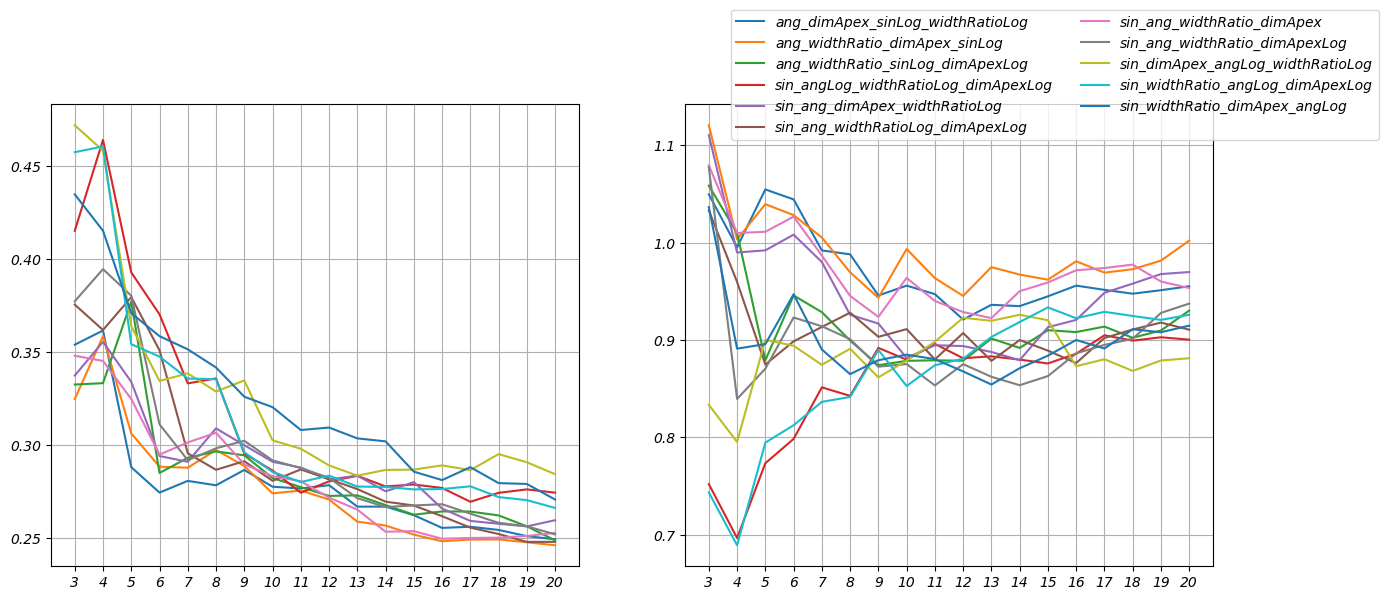

In [57]:
colors = ['blue', 'red', 'green', 'cyan']
marker = ['o', '^']
linetype = ['-', '--']
f, ax  = plt.subplots(ncols = 2, nrows = 1, figsize =[15, 6])
ax = ax.flatten()
for scoresI, scores in enumerate(['Silhouette', 'DaviesB']):
    for runI, run in enumerate(dfT['run'].unique()):
        dfF = dfT[(dfT['run'] == run)]
        lab = dfF.iloc[0][['col1', 'col2', 'col3', 'col4']].values

        ax[scoresI].plot(dfF['clusters'], dfF[scores],
                #  marker    = marker[pcaI], 
                    label     = f'{lab[0]}_{lab[1]}_{lab[2]}_{lab[3]}')
                #  color     = colors[geomTI],
                #  linestyle = linetype[scoresI])

    ax[scoresI].set_xticks(np.arange(dfT['clusters'].min(),dfT['clusters'].max()+1))
# plt.ylim([0,1.5])
# # plt.yticks(np.arange(0.35,1.5, 0.1))
    ax[scoresI].grid()
# plt.title('Kmeans Performance', loc = 'left')
plt.legend(bbox_to_anchor = [0.7,1.22], ncols = 2, loc = 'upper center')
# plt.xlabel('Clusters')
# plt.ylabel('Performance metric')
plt.show()

     init_type max_iter  covType    init  cluster  bic  aic_score  sil_score  \
324        100     diag        5  kmeans        3  NaN        NaN        NaN   
325        100     diag        5  kmeans        4  NaN        NaN        NaN   
326        100     diag        5  kmeans        5  NaN        NaN        NaN   
327        100     diag        5  kmeans        6  NaN        NaN        NaN   
328        100     diag        5  kmeans        7  NaN        NaN        NaN   
329        100     diag        5  kmeans        8  NaN        NaN        NaN   
330        100     diag        5  kmeans        9  NaN        NaN        NaN   
331        100     diag        5  kmeans       10  NaN        NaN        NaN   
332        100     diag        5  kmeans       11  NaN        NaN        NaN   
333        100     diag        5  kmeans       12  NaN        NaN        NaN   
334        100     diag        5  kmeans       13  NaN        NaN        NaN   
335        100     diag        5  kmeans

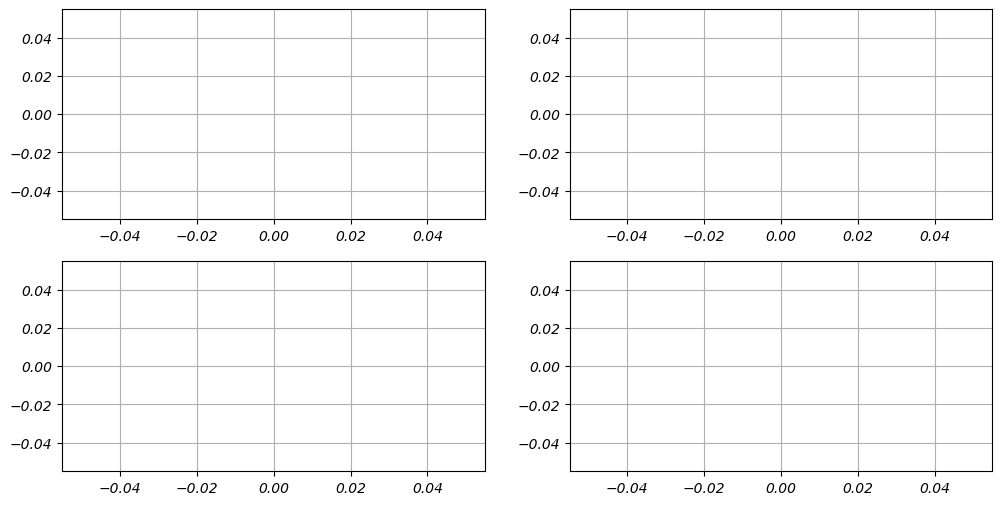

In [75]:
colors = ['blue', 'red', 'green', 'cyan']
marker = ['o', '^']
linetype = ['-', '--', ':', '-.']
f, ax = plt.subplots(ncols = 2, nrows = 2,figsize = [12,6])
ax    = np.array(ax).flatten()
for scoresI, scores in enumerate(['sil_score', 'dav_score', 'bic', 'aic_score']):
    for geomTI, geomT in enumerate(['reach', 'bend']):
        for pcaI, pca in enumerate(['True', 'False']):
            for covTI, covT in enumerate(['diag', 'tied', 'full']):
                for initI, init in enumerate([5, 10, 15]):

                    dfF = dfGS[(dfGS['geomType'] == geomT) & (dfGS['PCA'] == pca) & (dfGS['max_iter'] == covT) & (dfGS['covType'] == init)]
                    print(dfF)
                    ax[scoresI].plot(dfF['cluster'], dfF[scores], 
                            marker    = marker[pcaI], 
                            label     = f'{scores}_{geomT}_{pca}',
                            color     = colors[geomTI],
                            linestyle = linetype[scoresI])

    # plt.xticks(np.arange(dfKS['clusters'].min(),dfKS['clusters'].max()+1))
    # plt.ylim([0,1.5])
    # plt.yticks(np.arange(0.35,1.5, 0.1))
    ax[scoresI].grid()
    # plt.title('Kmeans Performance', loc = 'left')
    # plt.legend(bbox_to_anchor = [0.7,1.22], ncols = 2, loc = 'upper center')
    # plt.xlabel('Clusters')
    # plt.ylabel('Performance metric')
plt.show()

In [14]:
dfHD.head()
# dfHD['min_cluster_size'].unique(), dfHD['min_samples'].unique()

,metric,min_cluster_size,min_samples,DBCV,relVal,num_clusters,noise,geomType,PCA
0,chebyshev,100,80,-0.226692,0.046467,6,115456,reach,False
1,chebyshev,100,100,-0.219197,0.051797,10,69678,reach,False
2,chebyshev,120,80,-0.226692,0.046467,6,115456,reach,False
3,chebyshev,120,100,-0.339014,0.046802,6,117023,reach,False
4,chebyshev,120,120,-0.257851,0.035416,5,121509,reach,False


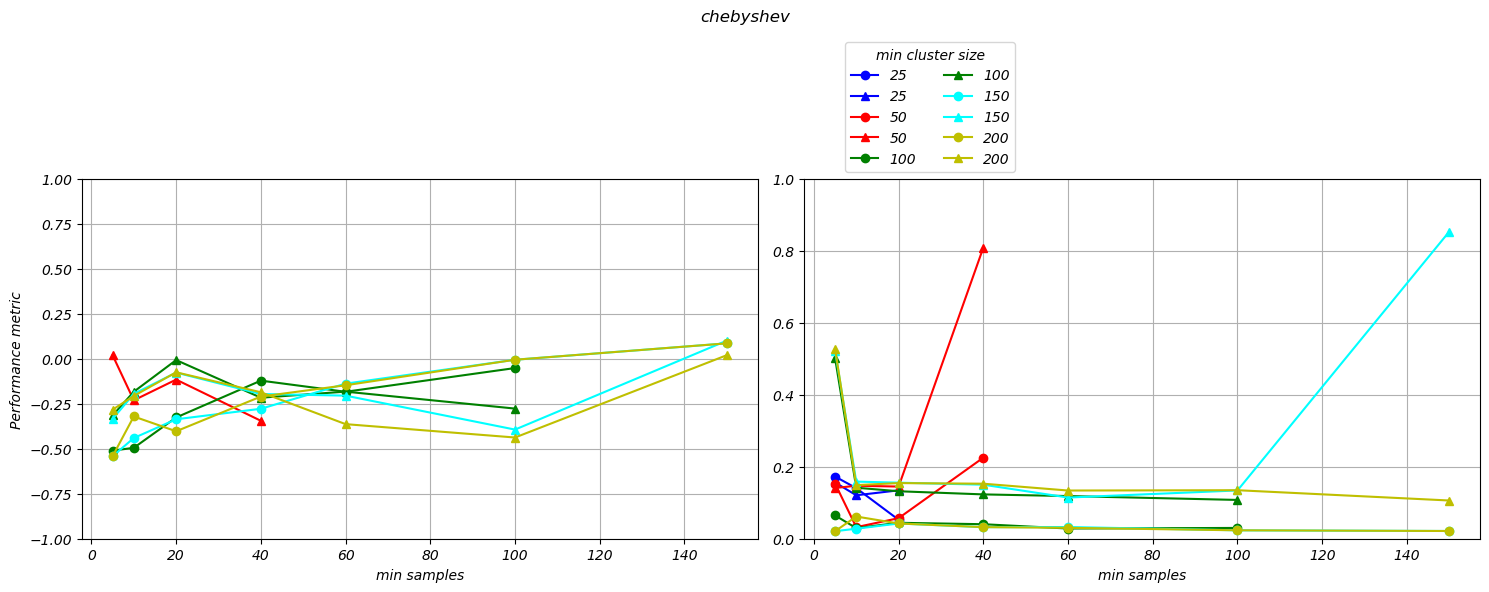

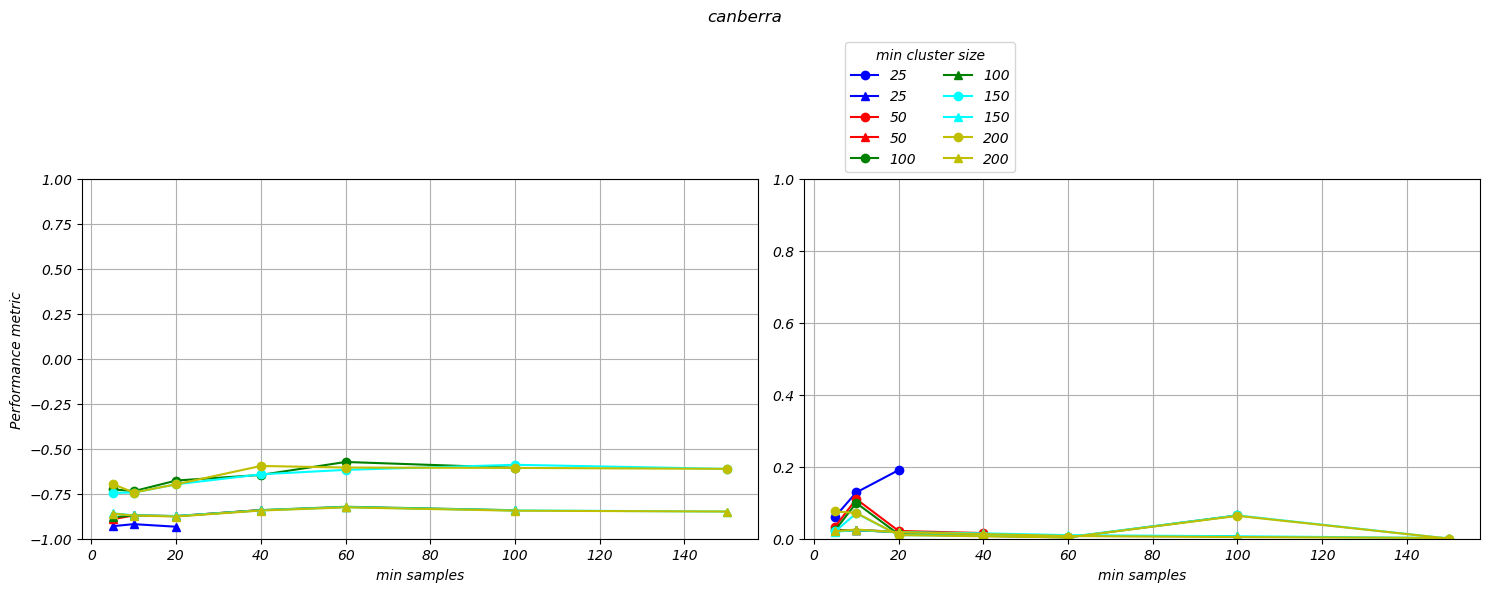

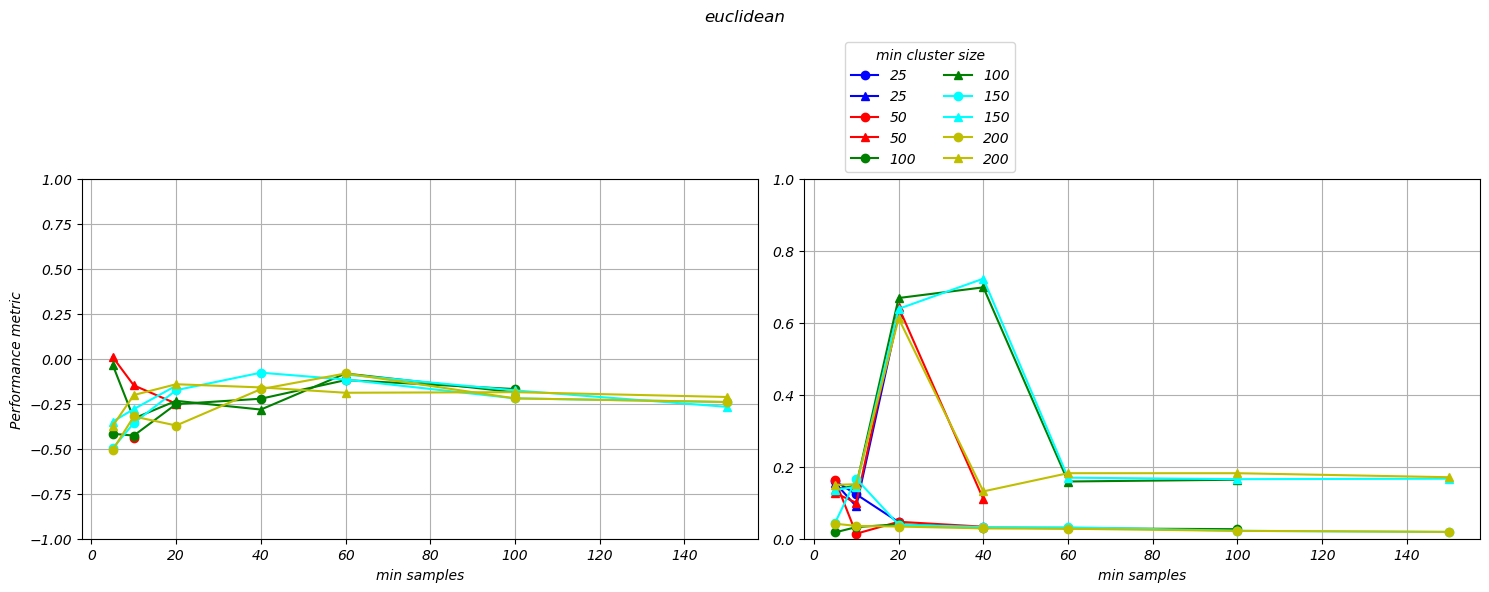

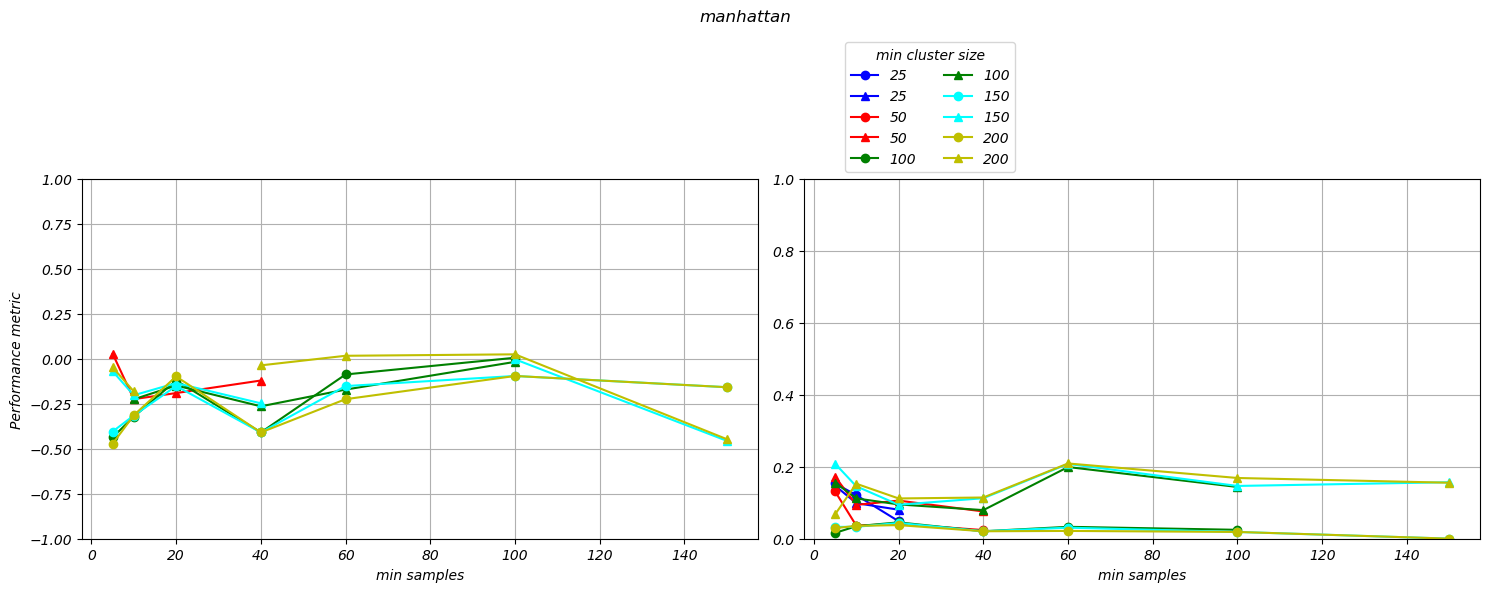

In [102]:
colors = ['blue', 'red', 'green', 'cyan', 'y']
marker = ['o', '^']
line = ['-', '--']
col = 0

for ai, alg in enumerate(dfHD['metric'].unique()):
    f, ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,6])
    for stI, st in enumerate(['DBCV', 'relVal']):
        for i, s in enumerate(dfHD['min_cluster_size'].unique()):
            for j, ch in enumerate(['_pca', '']):
                dfA = dfHD[dfHD['min_cluster_size'] == s]

                ax[stI].plot(dfA['min_samples'], dfA[f'{st}_{alg}_reach{ch}'],
                              label = f'{s}',
                              marker = marker[j],
                              color = colors[i]) 
                            #   linestyle = line[ai])
            
        ax[stI].grid()
    
    # ax[stI].set_xticks(np.arange(3,35))

        ax[stI].set_xlabel('min samples')
    f.suptitle(alg)
    ax[stI].legend(bbox_to_anchor = [0.05,1], ncols = 2, loc = 'lower left', title = 'min cluster size')
    ax[0].set_ylabel('Performance metric')
    ax[0].set_ylim([-1,1])
    ax[1].set_ylim([0,1])
    # ax[0].set_yticks(np.arange(0.4,1.8, 0.1))
    # f.suptitle('GMM Scores')
    plt.tight_layout()
    plt.show()

# Open files

In [206]:
cross = 50

## create global bend

In [6]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))
for i, f in tqdm(enumerate(allResultFiles), total = len(allResultFiles)):
    dfT = pd.read_csv(f)
    dfT['bendWidthRatio'] = dfT['bendMaxWidths'] / dfT['bendWidths']
    dfT['bendAng'] = dfT['ang']
    dfT['ang']     = dfT['bendAng'].mean()

    dfT['file_cont'] = f[-12:-10]
    dfT['file_id']   = f[-9:-7]
    if i == 0:
        df = dfT
    else:
        df = pd.concat([df, dfT], ignore_index=True)


NameError: name 'glob' is not defined

In [20]:
dropCols = ['n_nodes','obstr_type', 'wse', 'lakeflag', 'swot_orbit', 'max_width', 'type','include_flag', 'pfaf1', 'pfaf2', 'node_mean_max_width',
            'combined_reach_len', 'combined_reach_width',
            'combined_reach_max_width','networkGroup', 'elevOut', 'elevInn', 'distOut', 'distInn',
            'lineOut', 'lineInn', 'LROrthog', 'lineSlope', 'bendHeight',
            'calculated',  'apexP','infP','grod_id', 'hfalls_id','localCRS','geometry', 'bendLines']
df = df.drop(dropCols, axis = 1)




In [15]:
ds = df.to_xarray()

# Build safe compression encoding
encoding = {}
for var in ds.data_vars:
    dtype = ds[var].dtype
    if dtype.kind in {"i", "u", "f"}:  # integer, unsigned, float
        encoding[var] = {"zlib": True, "complevel": 4,"chunksizes": (10000,)}
fileName = directory + f'results/single_values/global_{cross}.nc'
if os.path.exists(fileName):
    os.remove(fileName)
ds.to_netcdf(fileName, format="NETCDF4", encoding=encoding)


## create global single values netcdf

In [ ]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))

In [ ]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))
for i, f in tqdm(enumerate(allResultFiles), total = len(allResultFiles)):
    dfT = pd.read_csv(f)
    if i == 0:
        df = dfT
    else:
        df = pd.concat([df, dfT], ignore_index=True)

100%|██████████| 43/43 [15:52<00:00, 22.15s/it]


## Open global single values netcdf

In [207]:
subsetCols = ['sin', 'bendSin', 'ang', 'apex', 'bendAng', 'bendWidthRatio', 'widthRatio','bendWidths', 'combined_reach_id', 'file_cont', 'file_id', 'bendDistOut']

In [208]:
directory = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/Congres/AGU_2025/presentation/analysis/'

In [209]:
df, dfG = open_dataset_morphology_clustering()

In [5]:
# f  = directory + 'results/single_values/global_50.nc'
# ds = xr.open_dataset(f)

# dfIn = ds.to_dataframe().reset_index()

# dsSubset = ds[subsetCols]
# dfIn = dsSubset.to_dataframe().reset_index()

# dfIn['bendAng'] = abs(dfIn['bendAng'])
# dfIn['ang']     = abs(dfIn['ang'])
# dfIn['dimApex'] = dfIn['apex'] / dfIn['bendWidths']
# dfIn['bendWidthRatio'] = 1 / dfIn['bendWidthRatio']

# dfIn['bendRank'] = dfIn.groupby(['combined_reach_id', 'file_cont'])['bendDistOut'].rank(ascending=False).astype(int)
# dfIn['bendID']   = dfIn['combined_reach_id'].astype(int).astype(str) + '_' + dfIn['bendRank'].astype(str)
# df = dfIn.copy()

# df = df[(df['bendSin'] < 6) & (df['dimApex'] < 35) & (df['bendAng'] < 0.1) & (df['bendWidthRatio'] > 0.02)]
# # df = df[(df['bendAng'] < 1) & (df['ang'] < 1)]

# dfG = df.groupby(['file_cont', 'combined_reach_id'], as_index = False).agg({
#     'file_id'    : 'first',
#     'sin'        : 'first',
#     'widthRatio' : 'first',
#     'dimApex'    : 'mean'  ,
#     'bendAng'    : 'mean'})
# dfG = dfG.rename(columns= {'bendAng':'ang'})

# Variables
- sin
- curv
- widthRatio
- apex

# Plot settings

In [210]:
labelSize = 15
tickSize  = 12

# Select and Normalize variables

#### Define FMP columns

In [211]:
FMPBendCols    = ['bendSin', 'dimApex', 'bendWidthRatio', 'bendAng']
FMPReachCols   = ['sin'    , 'dimApex', 'widthRatio'    , 'ang'    ]

FMPReachColsLog   = ['sin'    , 'dimApexLog', 'widthRatioLog'    , 'ang'    ]



### Apply logging

In [212]:
dfG = log_var(dfG, FMPReachCols)

#### Filter columns and drop NA values

In [213]:
dfBendCluster     = df.copy().dropna(subset  = FMPBendCols )
dfReachCluster    = dfG.copy().dropna(subset = FMPReachCols)

dfReachClusterLog = dfG.copy().dropna(subset = FMPReachColsLog)

In [214]:
dfG
# scale
# pca
# kmeans
# cluster cout/distribution
# map
# 
dfReachCluster, pca, Xpca = data_prep_clustering(dfReachCluster, ['sin', 'ang', 'dimApexLog', 'widthRatioLog'], True, 4, False) 
dfReachCluster            = applyKmeans(dfReachCluster,  ['sin', 'ang', 'dimApexLog', 'widthRatioLog'], 8)

#### Scale filtered dataframe

In [215]:



X_bend_scaled  = scale(dfBendCluster , FMPBendCols ) 
X_reach_scaled = scale(dfReachCluster, FMPReachCols)


X_reach_scaled_log = scale(dfReachClusterLog, FMPReachColsLog)

# Apply Principle component analysis

#### Apply Principle Component analysis

In [220]:
pca_bend   = PCA(n_components=len(FMPBendCols))
X_bend_pca = pca_bend.fit_transform(X_bend_scaled)

pca_reach   = PCA(n_components=len(FMPReachCols))
X_reach_pca = pca_reach.fit_transform(X_reach_scaled)
print(f'{"Bend PCA explained:":<25}{pca_bend.explained_variance_ratio_}')
print(f'{"Reach PCA explained:":<25}{pca_reach.explained_variance_ratio_}')

numPCA = 4
pcaBendCols = [f'PCA{P}' for P in range(1,numPCA+1)]
dfBendCluster[pcaBendCols] = X_bend_pca[:, :numPCA]

pcaReachCols = [f'PCA{P}' for P in range(1,numPCA+1)]
dfReachCluster[pcaReachCols] = X_reach_pca[:, :numPCA]

Bend PCA explained:      [0.41810003 0.27388352 0.22217531 0.08584114]
Reach PCA explained:     [0.45252232 0.25896247 0.20405895 0.08445626]


In [221]:
pca_reach_log   = PCA(n_components=len(FMPReachColsLog))
X_reach_pca_log = pca_reach_log.fit_transform(X_reach_scaled_log)
print(f'{"Reach PCA explained:":<25}{pca_reach_log.explained_variance_ratio_}')

numPCA = 4
pcaReachColsLog = [f'PCA{P}_log' for P in range(1,numPCA+1)]
dfReachClusterLog[pcaReachColsLog] = X_reach_pca_log[:, :numPCA]

Reach PCA explained:     [0.44621148 0.21697605 0.21132723 0.12548524]


### Plot variable importance

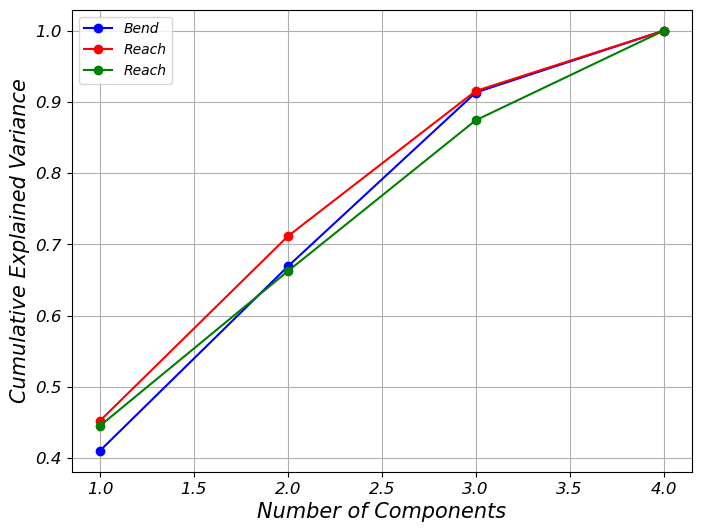

In [17]:
f, ax = plt.subplots(figsize = [8,6])
ax.plot(range(1, len(pca_bend.explained_variance_ratio_) + 1), 
         pca_bend.explained_variance_ratio_.cumsum(), marker='o', color = 'blue', label = 'Bend')
ax.plot(range(1, len(pca_reach.explained_variance_ratio_) + 1), 
         pca_reach.explained_variance_ratio_.cumsum(), marker='o', color = 'red', label = 'Reach')

ax.plot(range(1, len(pca_reach_log.explained_variance_ratio_) + 1), 
         pca_reach_log.explained_variance_ratio_.cumsum(), marker='o', color = 'green', label = 'Reach')

ax.tick_params(axis='both', which='major', labelsize=tickSize)
plt.xlabel('Number of Components', fontsize = labelSize)
plt.ylabel('Cumulative Explained Variance', fontsize = labelSize)
# plt.annotate('97%', [6, 0.96956738], [8,0.8], arrowprops={'width':0.5, 'color':'black', 'shrink':0.05}, fontsize = 14)
plt.legend()
plt.grid(True)
plt.savefig(directory + 'results/figures/PCA_FMP.png')
plt.show()

# f, ax = plt.subplots(figsize = [8,6])
# ax.plot(range(1, len(pca_bend.explained_variance_ratio_) + 1), 
#          pca_bend.explained_variance_ratio_.cumsum(), marker='o', color = 'blue', label = 'Bend')
# ax.plot(range(1, len(pca_reach.explained_variance_ratio_) + 1), 
#          pca_reach.explained_variance_ratio_.cumsum(), marker='o', color = 'red', label = 'Reach')

# ax.tick_params(axis='both', which='major', labelsize=tickSize)
# plt.xlabel('Number of Components', fontsize = labelSize)
# plt.ylabel('Cumulative Explained Variance', fontsize = labelSize)
# # plt.annotate('97%', [6, 0.96956738], [8,0.8], arrowprops={'width':0.5, 'color':'black', 'shrink':0.05}, fontsize = 14)
# plt.legend()
# plt.grid(True)
# plt.savefig(directory + 'results/figures/PCA_FMP.png')
# plt.show()

#### Show variable loadings for PCA

In [18]:
# Suppose you have original feature names
def print_loadings(X, XS, pca):
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f"var{i}" for i in range(XS.shape[1])]

    # Create a DataFrame of loadings
    loadings = pd.DataFrame(
        data=pca.components_.T**2,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    print(loadings.round(3))
print('Bend Loadings')
print_loadings(dfBendCluster[FMPBendCols], X_bend_scaled, pca_bend)
print()
print('Reach Loadings')
print_loadings(dfReachCluster[FMPReachCols], X_reach_scaled, pca_reach)

print()
print('Reach Loadings Log')
print_loadings(dfReachClusterLog[FMPReachColsLog], X_reach_scaled_log, pca_reach_log)

Bend Loadings
                  PC1    PC2    PC3    PC4
bendSin         0.502  0.001  0.004  0.493
dimApex         0.341  0.229  0.085  0.344
bendWidthRatio  0.006  0.328  0.665  0.000
bendAng         0.150  0.441  0.246  0.162

Reach Loadings
              PC1    PC2    PC3    PC4
sin         0.404  0.037  0.086  0.472
dimApex     0.275  0.355  0.019  0.351
widthRatio  0.151  0.181  0.657  0.011
ang         0.170  0.428  0.237  0.166

Reach Loadings Log
                 PC1    PC2    PC3    PC4
sin            0.336  0.085  0.108  0.472
dimApexLog     0.266  0.146  0.302  0.286
widthRatioLog  0.171  0.399  0.383  0.046
ang            0.227  0.369  0.207  0.196


# Outlier detection

In [144]:
def kde_dist(df, X, xlab, filterdf, ylog = False, title = ''):

    f, ax = plt.subplots(figsize = [6,4])
    if filterdf == False:
        sns.kdeplot(data = df, x = X, ax = ax, fill=True, color = 'red', legend = False)
    else:
        if X != 'widthRatio':
            sns.kdeplot(data = df[df['widthRatio'] == 1], x = X, ax = ax, fill=True, color = 'red'  , label = 'Single')
        sns.kdeplot(data = df[df['widthRatio'] < 1] , x = X, ax = ax, fill=True, color = 'green', label = 'Multi')
        plt.legend(title = 'Channel')
    ax.set_xlabel(xlab, fontsize = labelSize)
    ax.set_ylabel('Density', fontsize = labelSize)
    ax.set_title('KDE', fontsize = labelSize)
    if ylog == True:
        ax.set_yscale('log')
    plt.savefig('/home/6256481/River_Morphology/results/figures/' + f'{title}.png')
    plt.show()

def hist_plot(df, col, xlab, ylab, filterdf = False, ylog = True, xlog = True, title = ''):
    f, ax = plt.subplots(nrows = 1, ncols = 1, figsize  = [8,6], squeeze = False)

    r, c = 0,0
    bins = 100
    if filterdf == False:
        X = [df[col]]
        color = ['red']
        label = ['']
    else:
        X = [df.loc[df['widthRatio'] ==1, col], df.loc[df['widthRatio'] < 1, col]]
        color = ['red', 'green']
        label = ['Single', 'Multi']
    for i, x in enumerate(X):
        x = x.copy()
        x[x==0] = x[x> 0].min()/10
        bin_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), num=bins)
        # Create histogram
        ax[r,c].hist(x, bins=bin_edges, alpha=0.5, color = color[i], label = label[i])
        if label != '':
            ax[r,c].legend(fontsize = labelSize)
    if xlog == True:
        ax[r,c].set_xscale('log')
    if ylog == True:
        ax[r,c].set_yscale('log')
    ax[r,c].set_ylabel(ylab, fontsize = labelSize)
    ax[r,c].set_xlabel(xlab, fontsize = labelSize)

    f.suptitle('Histogram', fontsize = labelSize)
    plt.tight_layout()
    plt.savefig('/home/6256481/River_Morphology/results/figures/' + f'{title}.png')
    plt.show()

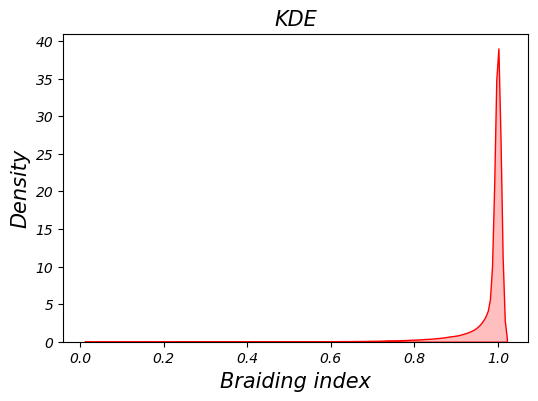

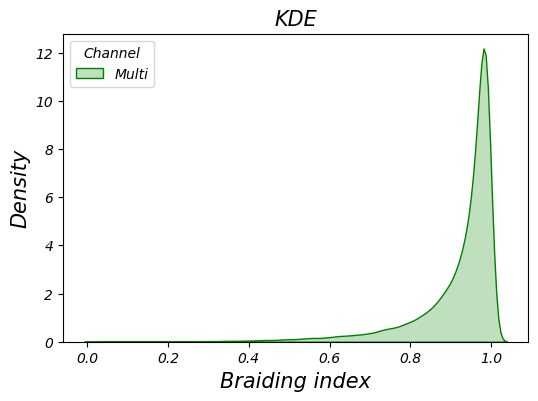

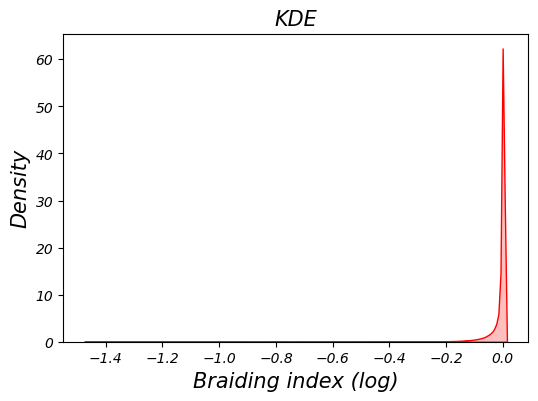

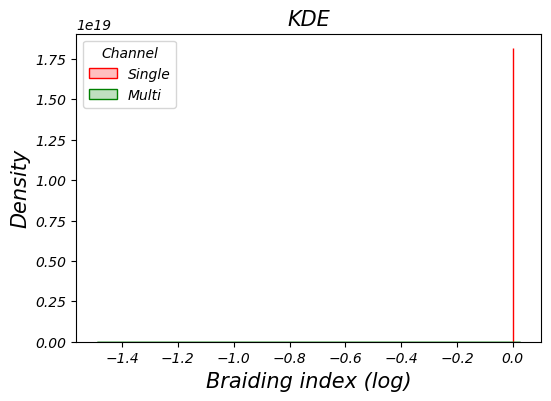

/tmp/ipykernel_164747/76396124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r,c].legend(fontsize = labelSize)


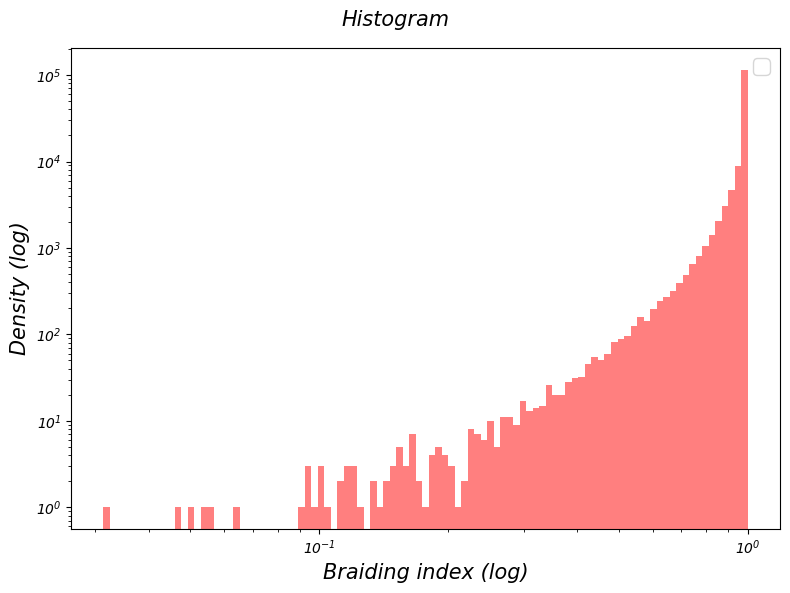

/tmp/ipykernel_164747/76396124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r,c].legend(fontsize = labelSize)


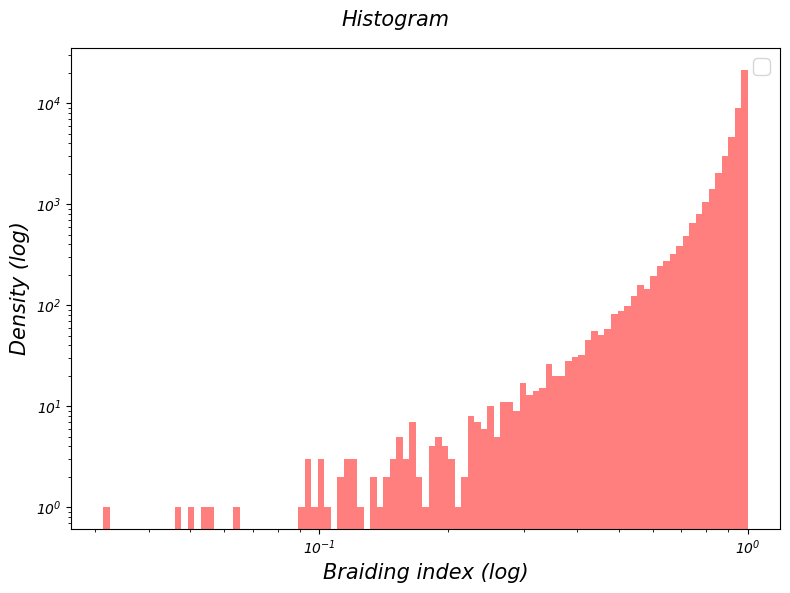

In [146]:
kde_dist(dfG, 'widthRatio'   , 'Braiding index'      , filterdf = False, title = 'BraidingIndex_KDE')
kde_dist(dfG, 'widthRatio'   , 'Braiding index'      , filterdf = True, title = 'BraidingIndex_KDE_MultiChannel')
kde_dist(dfG, 'widthRatioLog', 'Braiding index (log)', filterdf = False, title = 'BraidingIndex_KDE_Log')
kde_dist(dfG, 'widthRatioLog', 'Braiding index (log)', filterdf = True, title = 'BraidingIndex_KDE_MultiChannel_Log')
hist_plot(dfG                      , 'widthRatio', 'Braiding index (log)', 'Density (log)', filterdf = False, ylog = True, xlog = True, title = 'BraidingIndex_HIST_LogLog')
hist_plot(dfG[dfG['widthRatio'] <1], 'widthRatio', 'Braiding index (log)', 'Density (log)', filterdf = False, ylog = True, xlog = True, title = 'BraidingIndex_HIST_MultiChannel_LogLog')

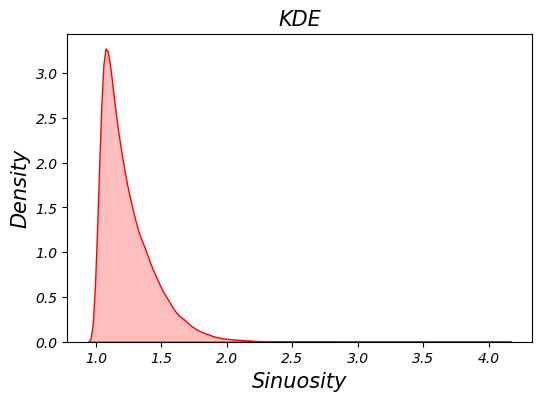

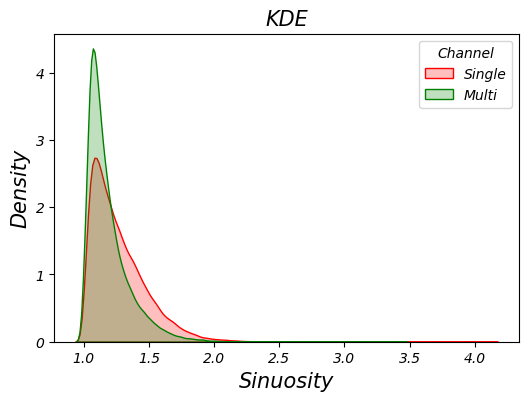

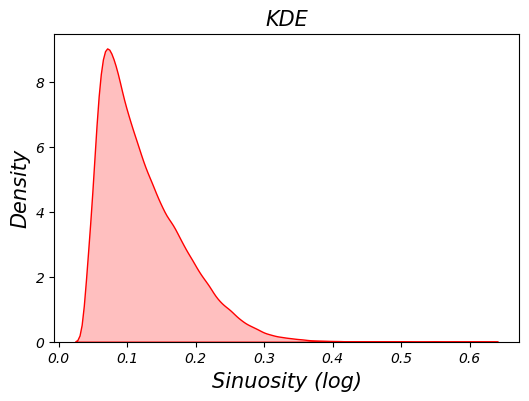

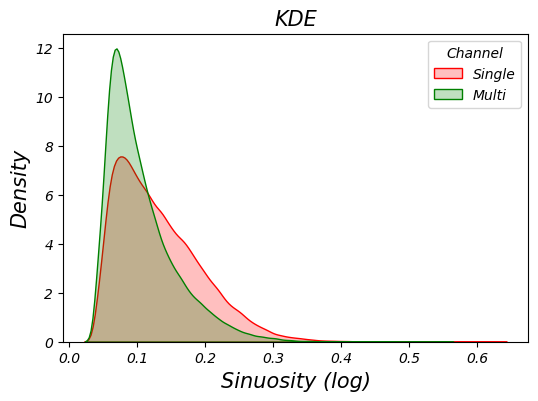

/tmp/ipykernel_164747/76396124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r,c].legend(fontsize = labelSize)


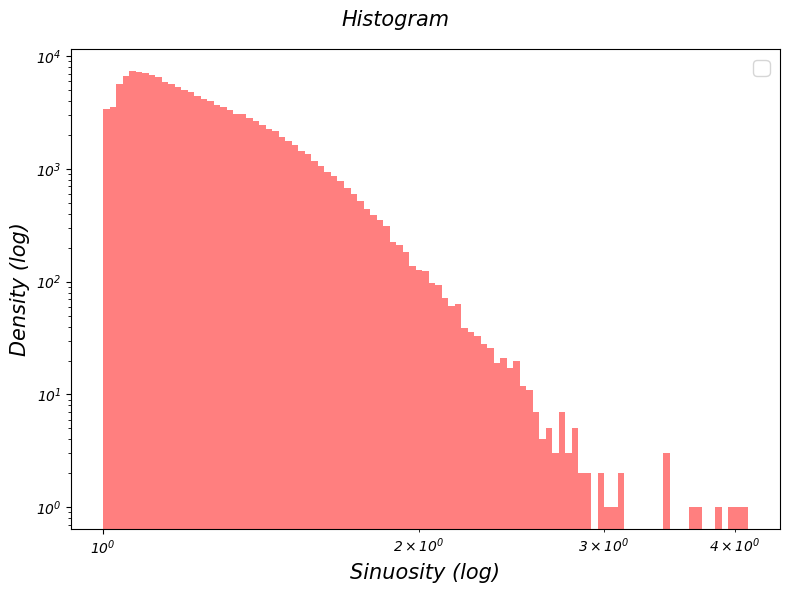

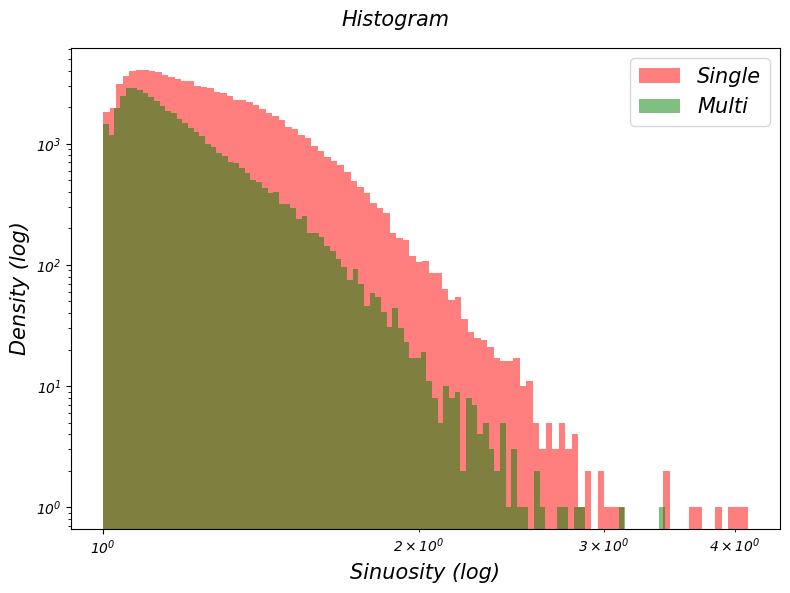

In [148]:
kde_dist(dfG, 'sin'   , 'Sinuosity'      , filterdf = False, title = 'Sin_KDE')
kde_dist(dfG, 'sin'   , 'Sinuosity'      , filterdf = True , title = 'Sin_KDE_MultiChannel')
kde_dist(dfG, 'sinLog', 'Sinuosity (log)', filterdf = False, title = 'Sin_KDE_Log')
kde_dist(dfG, 'sinLog', 'Sinuosity (log)', filterdf = True , title = 'Sin_KDE_MultiChannel_Log')
hist_plot(dfG, 'sin', 'Sinuosity (log)', 'Density (log)', filterdf = False, ylog = True, xlog = True, title = 'Sin_HIST_LogLog')
hist_plot(dfG, 'sin', 'Sinuosity (log)', 'Density (log)', filterdf = True, ylog = True, xlog = True, title = 'Sin_HIST_MultiChannel_LogLog')

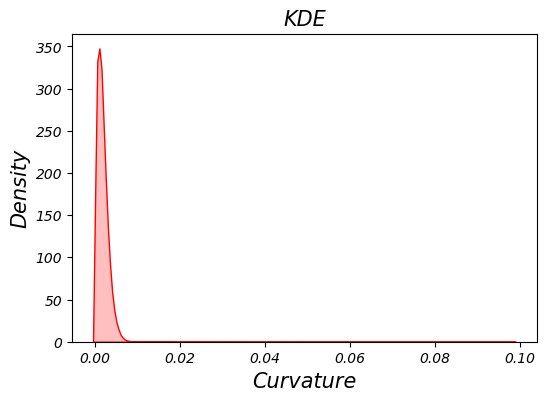

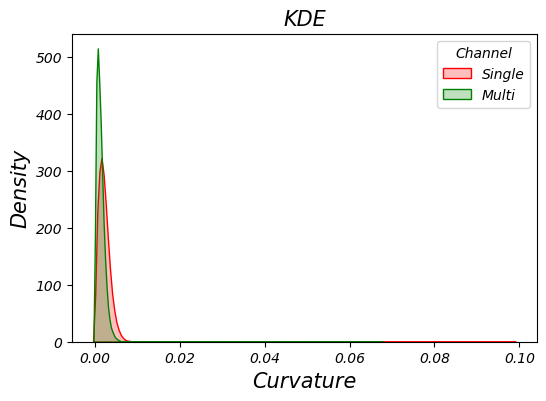

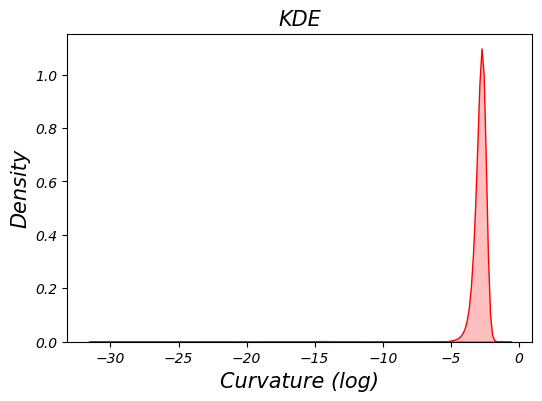

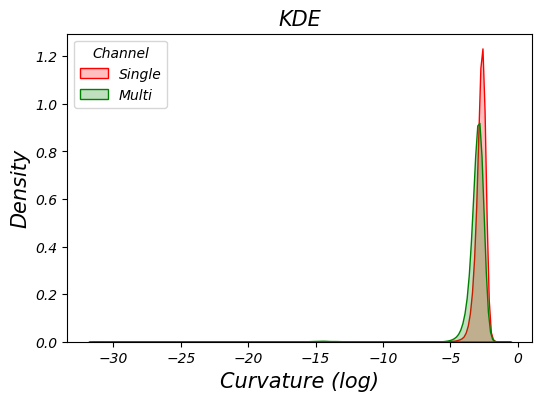

/tmp/ipykernel_164747/76396124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r,c].legend(fontsize = labelSize)


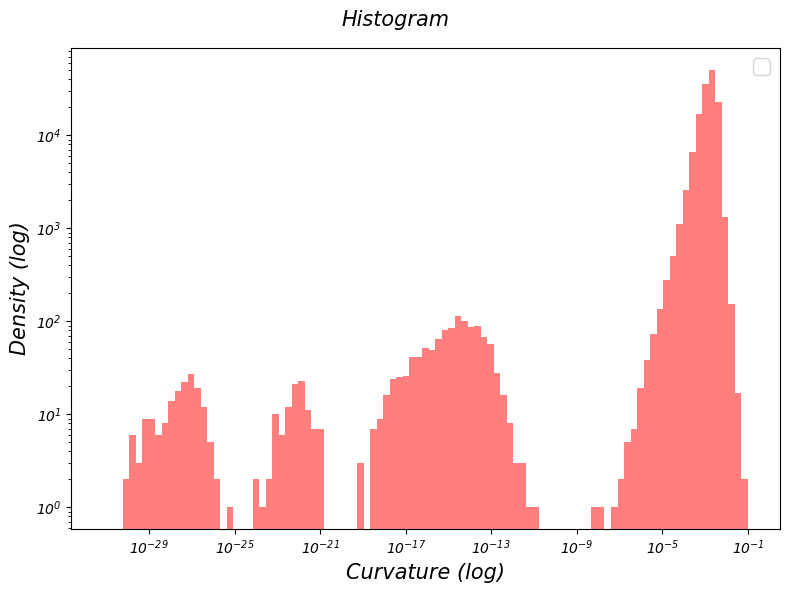

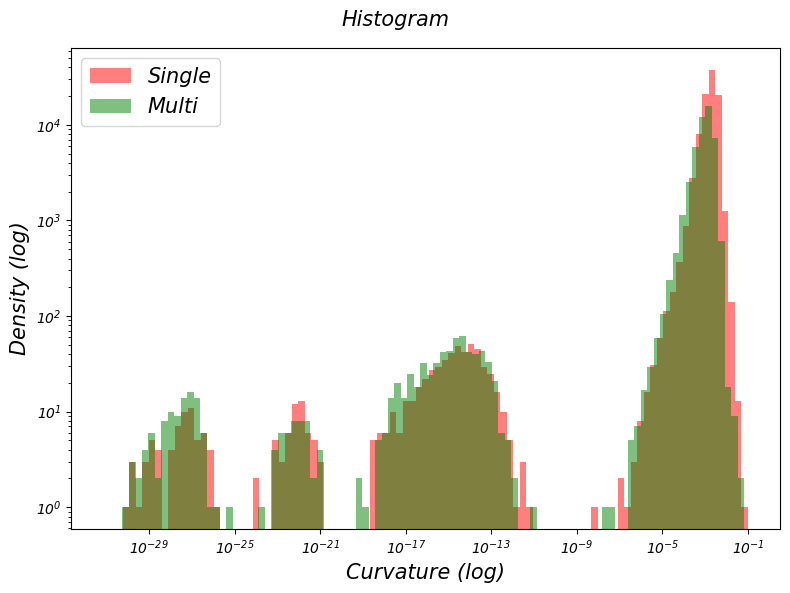

In [149]:
kde_dist(dfG , 'ang'   , 'Curvature'      , filterdf = False, title = 'Ang_KDE')
kde_dist(dfG , 'ang'   , 'Curvature'      , filterdf = True , title = 'Ang_KDE_MultiChannel')
kde_dist(dfG , 'angLog', 'Curvature (log)', filterdf = False, title = 'Ang_KDE_Log')
kde_dist(dfG , 'angLog', 'Curvature (log)', filterdf = True , title = 'Ang_KDE_MultiChannel_Log')
hist_plot(dfG, 'ang'   , 'Curvature (log)', 'Density (log)', filterdf = False, ylog = True, xlog = True, title = 'Ang_HIST_LogLog')
hist_plot(dfG, 'ang'   , 'Curvature (log)', 'Density (log)', filterdf = True , ylog = True, xlog = True, title = 'Ang_HIST_MultiChannel_LogLog')

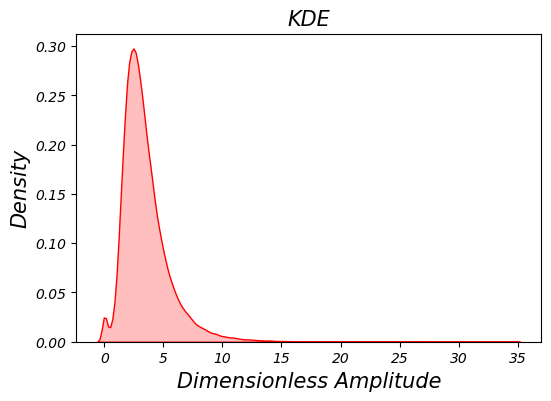

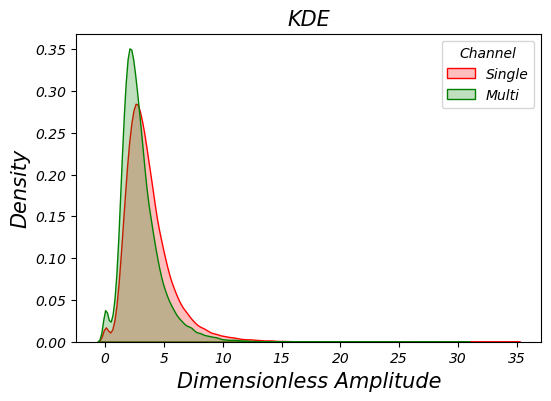

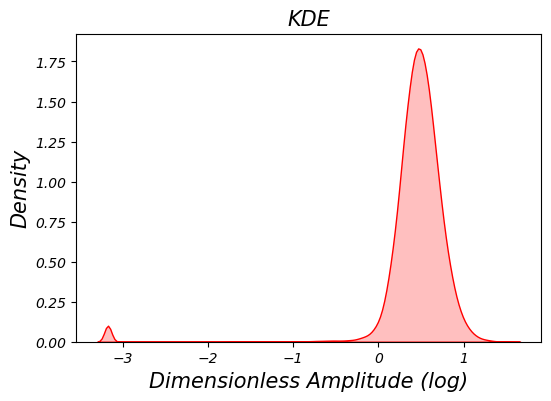

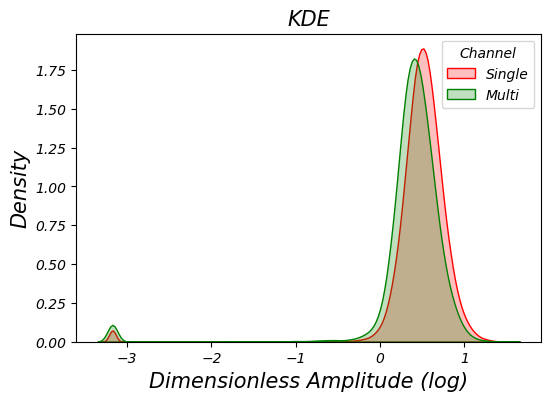

/tmp/ipykernel_164747/76396124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r,c].legend(fontsize = labelSize)


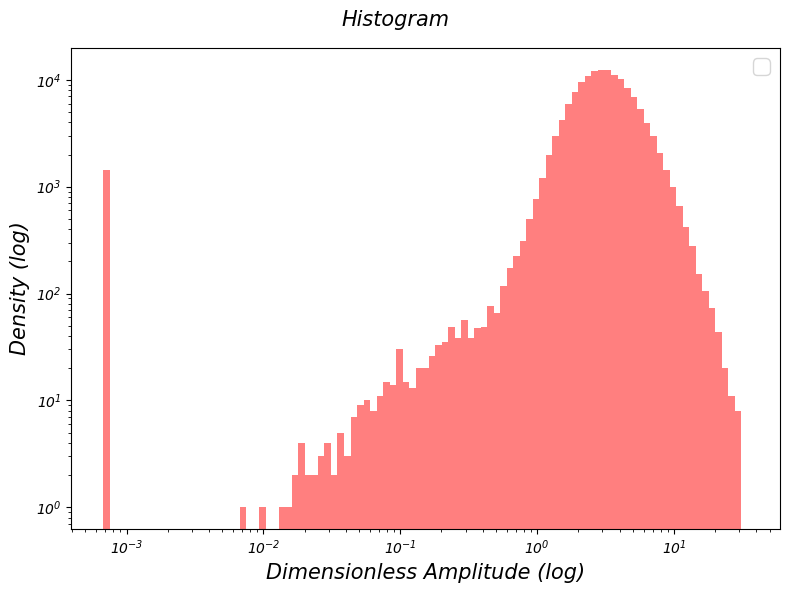

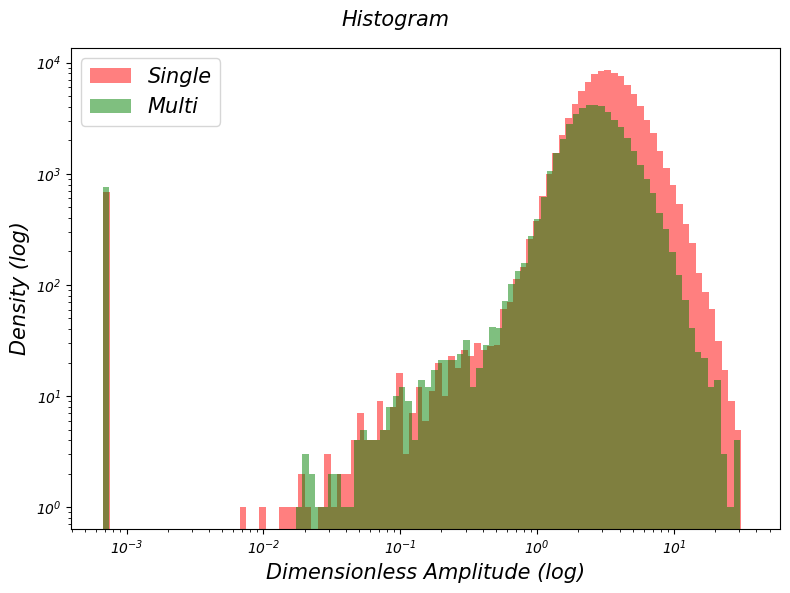

In [150]:
kde_dist(dfG , 'dimApex'   , 'Dimensionless Amplitude'      , filterdf = False, title = 'Apex_KDE')
kde_dist(dfG , 'dimApex'   , 'Dimensionless Amplitude'      , filterdf = True , title = 'Apex_KDE_MultiChannel')
kde_dist(dfG , 'dimApexLog', 'Dimensionless Amplitude (log)', filterdf = False, title = 'Apex_KDE_Log')
kde_dist(dfG , 'dimApexLog', 'Dimensionless Amplitude (log)', filterdf = True , title = 'Apex_KDE_MultiChannel_Log')
hist_plot(dfG, 'dimApex'   , 'Dimensionless Amplitude (log)', 'Density (log)', filterdf = False, ylog = True, xlog = True, title = 'Apex_HIST_LogLog')
hist_plot(dfG, 'dimApex'   , 'Dimensionless Amplitude (log)', 'Density (log)', filterdf = True , ylog = True, xlog = True, title = 'Apex_HIST_MultiChannel_LogLog')

### Distributions per var

In [162]:
dfIn['bendWidthRatio'].min(), dfIn['bendWidthRatio'].max()
dfIn['widthRatio'].min(), dfIn['widthRatio'].max()

(0.0053729257492764, 1.0)

In [192]:
dfIn[dfIn['bendSin'] > 6].shape[0], dfIn[dfIn['dimApex'] >35].shape[0], dfIn[dfIn['bendAng'] >0.1].shape[0], dfIn[dfIn['bendWidthRatio'] <0.02].shape[0]

# sin: <2.5
# dimApex:< 20
# ang: -
# widthRatio: >0.25


(234, 196, 341, 241)

In [173]:
dfT = dfIn[(dfIn['bendSin'] < 6) & (dfIn['dimApex'] < 35) & (dfIn['bendAng'] < 5) & (dfIn['bendWidthRatio'] > 0.02)]

In [181]:
dfT.shape[0], dfIn.shape[0], dfT.shape[0]- dfIn.shape[0], 750 / 1400000

(1489745, 1490496, -751, 0.0005357142857142857)

In [178]:
dfT[dfT['ang'] == dfT['ang'].max()][['ang', 'bendAng']]

,ang,bendAng
966712,3.394507e+11,0.002567
966713,3.394507e+11,0.005854
966714,3.394507e+11,0.004738
966715,3.394507e+11,0.003049
966716,3.394507e+11,0.003020
...,...,...
996953,3.394507e+11,0.002388
996954,3.394507e+11,0.002883
996955,3.394507e+11,0.000806
996956,3.394507e+11,0.002145


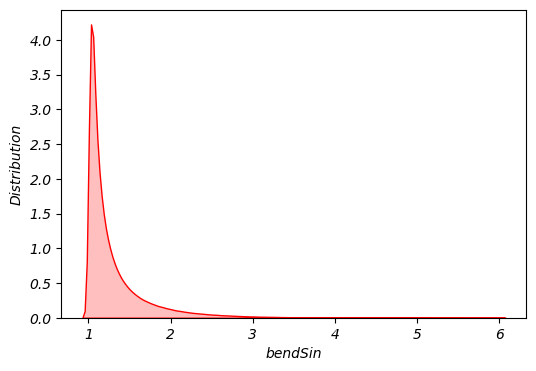

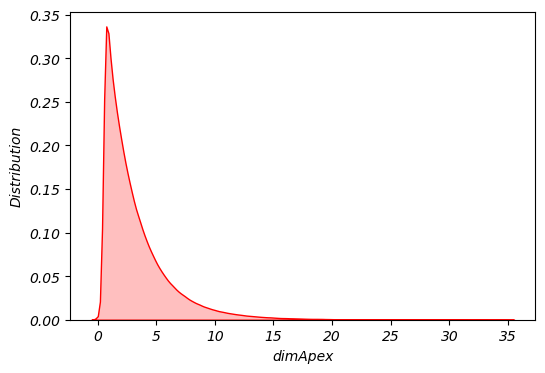

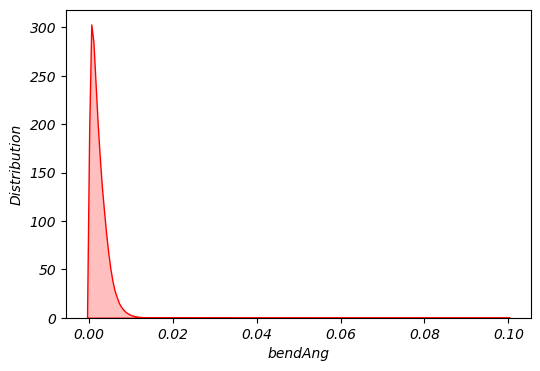

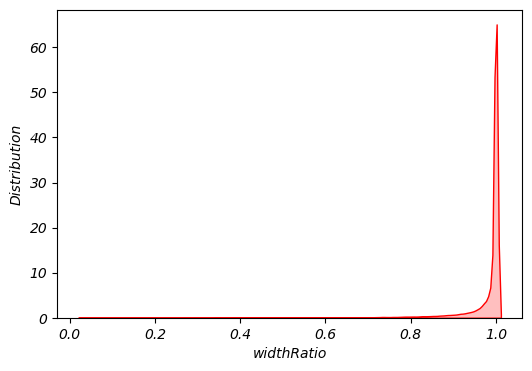

In [217]:
def kde_dist(df, cols):
     for col in cols:
        f, ax = plt.subplots(figsize = [6,4])
        sns.kdeplot(data = df, x = col, ax = ax, fill=True, color = 'red', legend = False)
        ax.set_xlabel(col)
        ax.set_ylabel('Distribution')
        plt.show()

kde_dist(df, ['bendSin', 'dimApex', 'bendAng', 'widthRatio'])

In [48]:
checkClusters = [3,4,5,6,7,8,9,10]

In [218]:
def add_labels(df,cols, clusters):

    kmeans = KMeans(n_clusters=clusters,init='k-means++',random_state=42)
    df[f'KMeans_pca_{clusters}']=  kmeans.fit_predict(df[cols])
    return df
for i in checkClusters:
    dfBendCluster = add_labels(dfBendCluster  , pcaBendCols , i)
    dfReachCluster = add_labels(dfReachCluster, pcaReachCols, i)



#### Check number of values per cluster
If single cluster exists with very few or single value probably outlier

In [219]:
for i in checkClusters:
    N,U = np.unique(dfBendCluster[f'KMeans_pca_{i}'], return_counts=True)
    print(f"{i:<2}", f'{str(list(N)):<30}', list(U))


3  [0, 1, 2]                      [1098019, 312346, 79128]
4  [0, 1, 2, 3]                   [955503, 271302, 78108, 184580]
5  [0, 1, 2, 3, 4]                [864037, 265386, 77409, 70334, 212327]
6  [0, 1, 2, 3, 4, 5]             [772537, 72418, 77103, 51755, 286735, 228945]
7  [0, 1, 2, 3, 4, 5, 6]          [650780, 251040, 76711, 66217, 45664, 314039, 85042]
8  [0, 1, 2, 3, 4, 5, 6, 7]       [695462, 249911, 76836, 27812, 107691, 269927, 2207, 59647]
9  [0, 1, 2, 3, 4, 5, 6, 7, 8]    [604912, 77834, 76440, 29176, 112260, 226256, 1002, 48887, 312726]
10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] [572177, 127657, 76303, 14681, 54245, 207939, 1013, 53609, 300292, 81577]


In [220]:
for i in checkClusters:
    N,U = np.unique(dfReachCluster[f'KMeans_pca_{i}'], return_counts=True)
    print(f"{i:<2}", f'{str(list(N)):<30}', list(U))

3  [0, 1, 2]                      [7306, 96041, 37227]
4  [0, 1, 2, 3]                   [7124, 94293, 36347, 2810]
5  [0, 1, 2, 3, 4]                [6781, 47812, 12544, 2809, 70628]
6  [0, 1, 2, 3, 4, 5]             [6648, 47526, 16505, 2809, 60468, 6618]
7  [0, 1, 2, 3, 4, 5, 6]          [6605, 43200, 15153, 2808, 54881, 3356, 14571]
8  [0, 1, 2, 3, 4, 5, 6, 7]       [2334, 14884, 2801, 53540, 3334, 39612, 9695, 14374]
9  [0, 1, 2, 3, 4, 5, 6, 7, 8]    [2314, 13186, 2800, 41484, 7242, 40336, 9500, 21367, 2345]
10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] [1186, 12954, 2799, 39948, 7180, 39205, 3889, 21183, 2295, 9935]


#### Plot variables against each other to see problamatic variable

In [157]:
dfOut = dfBendCluster[dfBendCluster['KMeans_pca_7'] == 2]

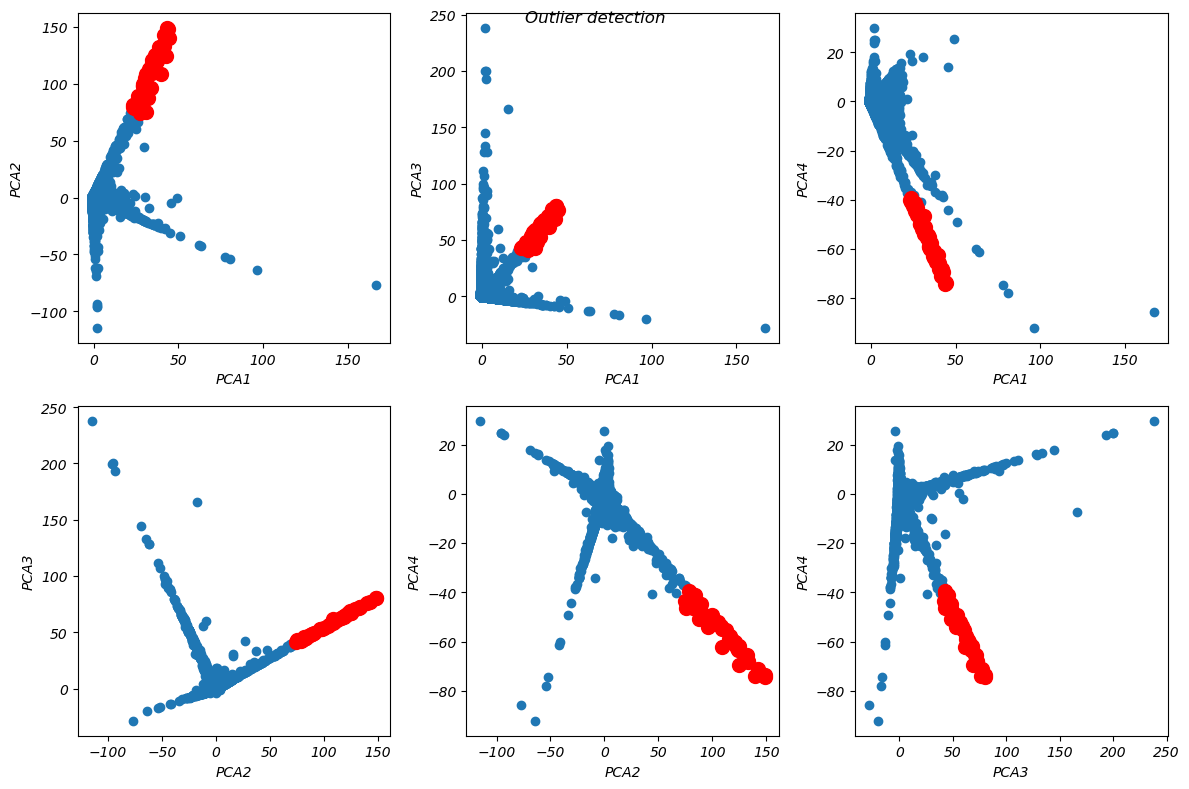

In [126]:
f, ax = plt.subplots(ncols = 3, nrows = 2, figsize = [12,8])
x = ['PCA1', 'PCA1', 'PCA1', 'PCA2', 'PCA2', 'PCA3']
y = ['PCA2', 'PCA3', 'PCA4', 'PCA3', 'PCA4', 'PCA4']
C, R = -1,0
for i in range(6):
    # print(i, R, C)
    if i == 3:

        R += 1
        C  = 0
    else:

        C += 1

    ax[R,C].scatter(dfBendCluster[x[i]], dfBendCluster[y[i]])
    ax[R,C].scatter(dfOut[x[i]], dfOut[y[i]], s = 100, c = 'red')
    ax[R,C].set_xlabel(x[i])
    ax[R,C].set_ylabel(y[i])
    
plt.tight_layout()
f.suptitle('Outlier detection')
plt.show()

In [153]:
dfG['ang'].max(), df['bendAng'].max()

(0.03750743667489536, 0.96677103)

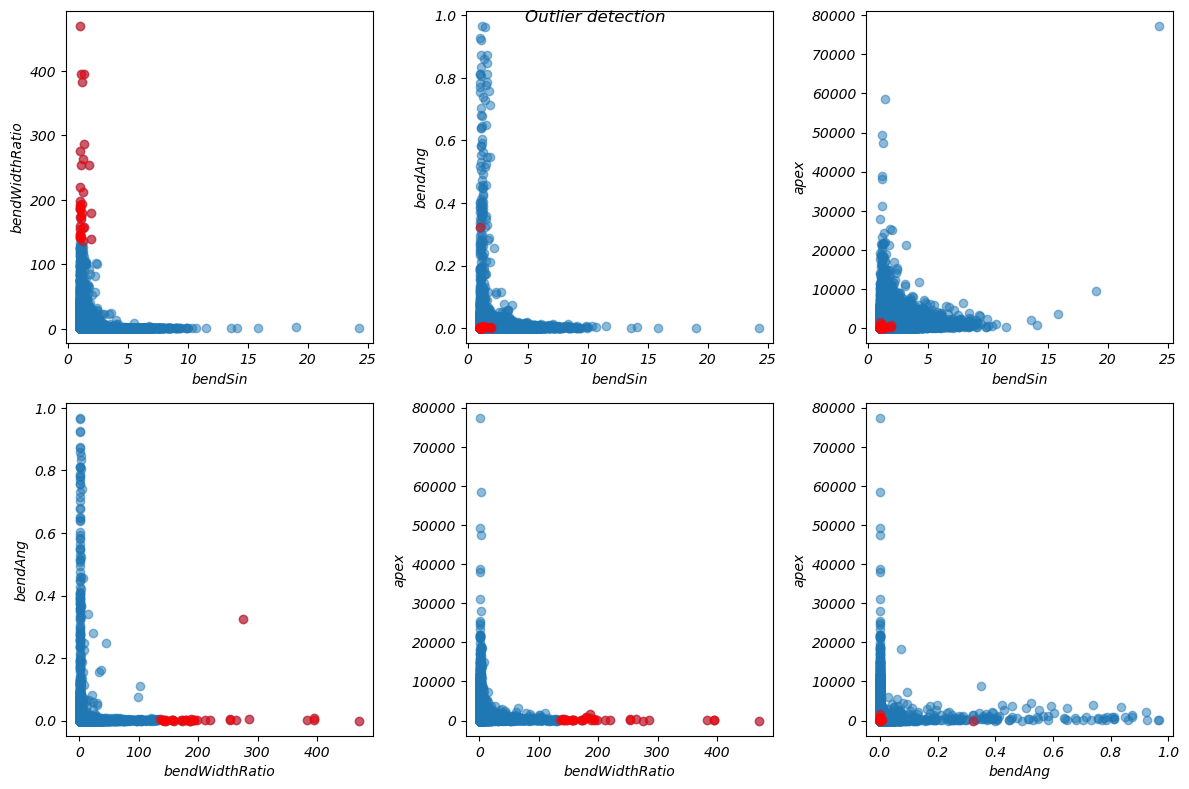

In [158]:
f, ax = plt.subplots(ncols = 3, nrows = 2, figsize = [12,8])
x = ['bendSin', 'bendSin', 'bendSin', 'bendWidthRatio', 'bendWidthRatio', 'bendAng']
y = ['bendWidthRatio', 'bendAng', 'apex', 'bendAng', 'apex', 'apex']
C, R = -1,0
for i in range(6):
    # print(i, R, C)
    if i == 3:

        R += 1
        C  = 0
    else:

        C += 1

    ax[R,C].scatter(dfBendCluster[x[i]], dfBendCluster[y[i]], alpha = 0.5)
    ax[R,C].scatter(dfOut[x[i]], dfOut[y[i]], c = 'red', alpha = 0.5)
    ax[R,C].set_xlabel(x[i])
    ax[R,C].set_ylabel(y[i])
    
plt.tight_layout()
f.suptitle('Outlier detection')
plt.show()

# Functions

/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_13518/3788156659.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, i].set_xticklabels(


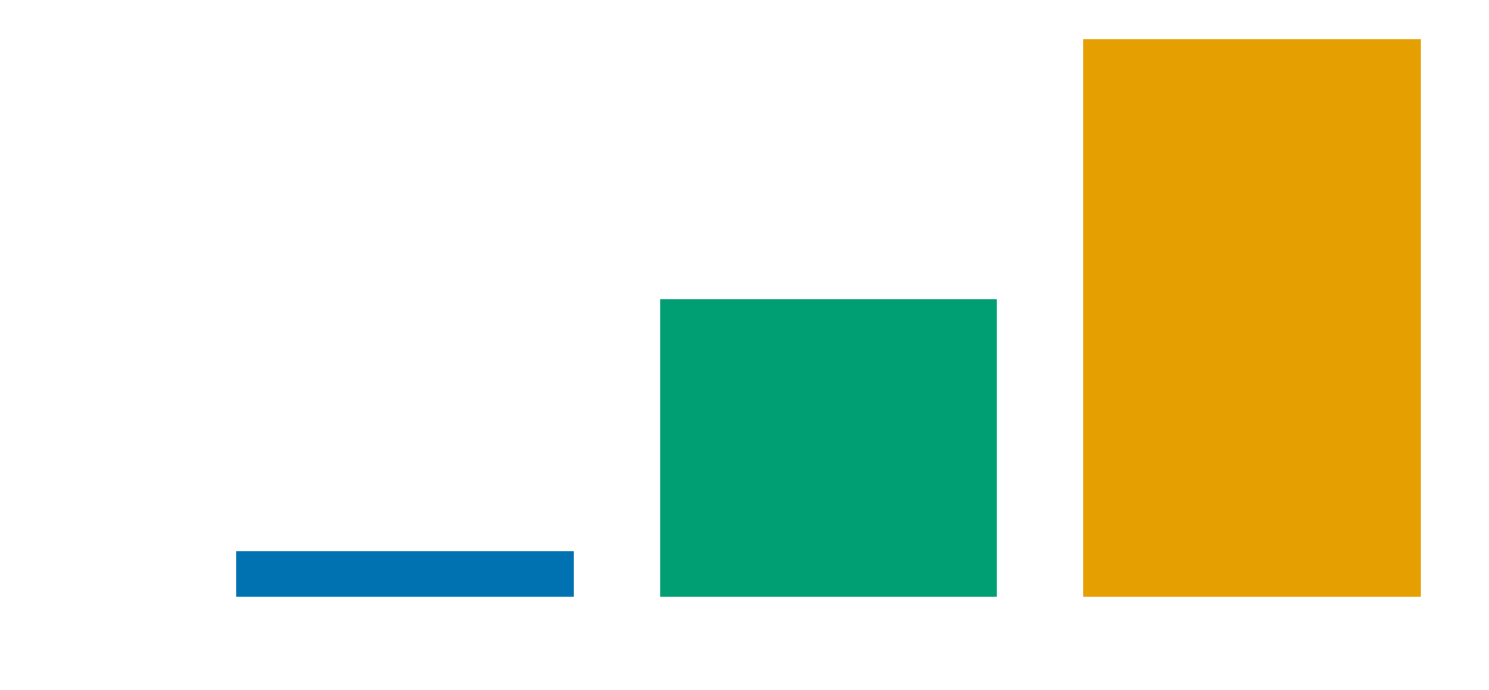

In [228]:
# def bar_cluster_distribution_plot(df, C, cols, geomT):

#     f,ax =plt.subplots(ncols = len(cols), nrows = 1, squeeze = False, figsize = [15,7], sharey =True)
    
#     for i in range(len(cols)):
#         if cols[i] == '':
#             col = f'{C}'
#         else:
#             col = f'{C}_{cols[i]}'

#         values                = df[col]
#         unique_labels, counts = np.unique(values, return_counts=True)

#         # Optional: sort clusters by label
#         sorted_indices = np.argsort(unique_labels)
#         unique_labels  = unique_labels[sorted_indices]
#         counts         = counts[sorted_indices]


#         ax[0,i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
#         # ax[0,i].set_yticks(np.arange(0, 1.2e6, 5e4))
#         ax[0,i].set_xlabel("Cluster", fontsize = 25)
        
#         ax[0,i].set_title(cols[i])
#         ax[0,i].grid(axis='y', linestyle='--', alpha=0.7)
#         ax[0,i].tick_params(axis='both', which='major', labelsize=18)
#     ax[0,0].set_ylabel("Number of reaches", fontsize = 25)
    
#     plt.tight_layout()
#     f= '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/Congres/AGU_2025/presentation/analysis/'
#     # plt.savefig(directory + f'results/figures/bar_cluster_distribution_morpgology_{C}.png', dpi = 1000)
#     plt.savefig(f + f'bar_cluster_distribution_morpgology_{C}.svg', dpi = 1000)
#     plt.show()
def bar_cluster_distribution_plot(df, C, cols, geomT):
    f, ax = plt.subplots(ncols=len(cols), nrows=1, squeeze=False, figsize=[15, 7], sharey=True)
    f.patch.set_alpha(0)  # transparent figure
    # colors = ['#0072B2', '#009E73', '#E69F00', '#F0E442', '#56B4E9', '#D55E00', '#CC79A7', '#000000']

    palette = ['#0072B2', '#009E73', '#E69F00', '#F0E442', '#56B4E9', '#D55E00', '#CC79A7', '#000000']
    




    for i in range(len(cols)):
        col = f'{C}' if cols[i] == '' else f'{C}_{cols[i]}'
        values = df[col]
        unique_labels, counts = np.unique(values, return_counts=True)
        bar_colors = [palette[j % len(palette)] for j, _ in enumerate(unique_labels)]
        
        sorted_indices = np.argsort(unique_labels)
        unique_labels = unique_labels[sorted_indices]
        counts = counts[sorted_indices]

        ax[0, i].set_facecolor('none')  # transparent axes
        ax[0, i].bar([str(lbl) for lbl in unique_labels], counts,
             color=bar_colors, edgecolor='white')
        # ax[0, i].bar([str(lbl) for lbl in unique_labels], counts, color=colors[i], edgecolor='white')
        # ax[0, i].set_xticks(["A", "B", 'C'], fontsize=30, color='white')
        label_map = ['Multi-channel\nStraight', "Single channel\nSinuous", 'Single channel\nStraight']
        ax[0, i].set_xticklabels(
            [label_map[lbl] for lbl in unique_labels],
            fontsize=35,
            color='white'
            )
        # ax[0, i].set_xlabel("Cluster", fontsize=30, color='white')
        ax[0, i].set_title(cols[i], color='white')
        # ax[0, i].grid(axis='y', linestyle='--', alpha=0.3, color='white')
        ax[0, i].tick_params(axis='both', which='major', labelsize=25, colors='white')
        for spine in ax[0, i].spines.values():
            spine.set_color('white')
    ax[0, i].spines['top'].set_visible(False)
    ax[0, i].spines['right'].set_visible(False)

    ax[0, 0].set_ylabel("Number of reaches", fontsize=30, color='white')

    plt.tight_layout()
    save_dir = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/Congres/AGU_2025/presentation/analysis/'
    plt.savefig(save_dir + f'bar_cluster_distribution_morpgology_{C}.svg',
                dpi=1000, facecolor='none', edgecolor='none')
    plt.show()

bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_3', [''], 'Reach')


In [33]:
def plot_kde_cluster(df, cols, clustering,clusters):
    if (len(cols) %2) == 0:
        ncols = 2
        nrows = int(len(cols) /2)
    else:
        ncols = 3
        nrows = int(len(cols) /3)

    colRange = [[1,2], [0,0.04], [0,15], [0.1,1.1]]
    for c in range(clusters):
        f, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = [15, 8])
        count = 0
        for i in range(nrows):
            for j in range(ncols):
                data = df[df[clustering] == c]
                L = sns.kdeplot(data = data, x = cols[count], ax=axs[i,j], fill=True, color = 'red', legend = False)

                
                axs[i,j].set_xlabel(cols[count], fontsize = 10)
                axs[i,j].grid(True, which="both", ls="--", lw=0.5)
                axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
                # axs[i,j].set_ylim([0,0.06])
                axs[i,j].set_xlim(colRange[count])
                # axs[i,j].set_xticks(np.arange(0,1.1,0.1))
            
            
                count +=1
        f.suptitle(f'Number of clusters: {clusters}, cluster: {c}')
        # plt.savefig(directory + f'results/figures/KDE_{clusters}_{clusterVal}_{CH}.png')
        plt.show()

# Kmeans clustering

## Elbow Curve

In [76]:
def kmeans_elbow(X, k):
    # === Elbow Method to determine optimal k ===
    inertia = []
    k_range = range(1, k)

    
    for mi in [300]:
        for n_init in [5]:
            inter = []
            for k in tqdm(k_range):
                kmeans = KMeans(n_clusters   = k,
                                init         = 'k-means++',
                                random_state = 42,
                                max_iter     = mi)
                kmeans.fit(X)
                inter.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center
            inertia.append(inter)
    return k_range, inertia




In [143]:
vars = [X_bend_scaled, dfBendCluster[pcaBendCols], X_reach_scaled, dfReachCluster[pcaReachCols]]
krL, inL = [], []
for i in range(len(vars)):
    kr   ,  inertia      = kmeans_elbow(vars[i] , 25)
    krL.append(kr)
    inL.append(inertia)

# krPCA,  inertiaPCA   = kmeans_elbow(dfCluster[clusterCols] , 25)

100%|██████████| 24/24 [02:10<00:00,  5.42s/it]


No difference between different max_iter and n_init settings to stick to default

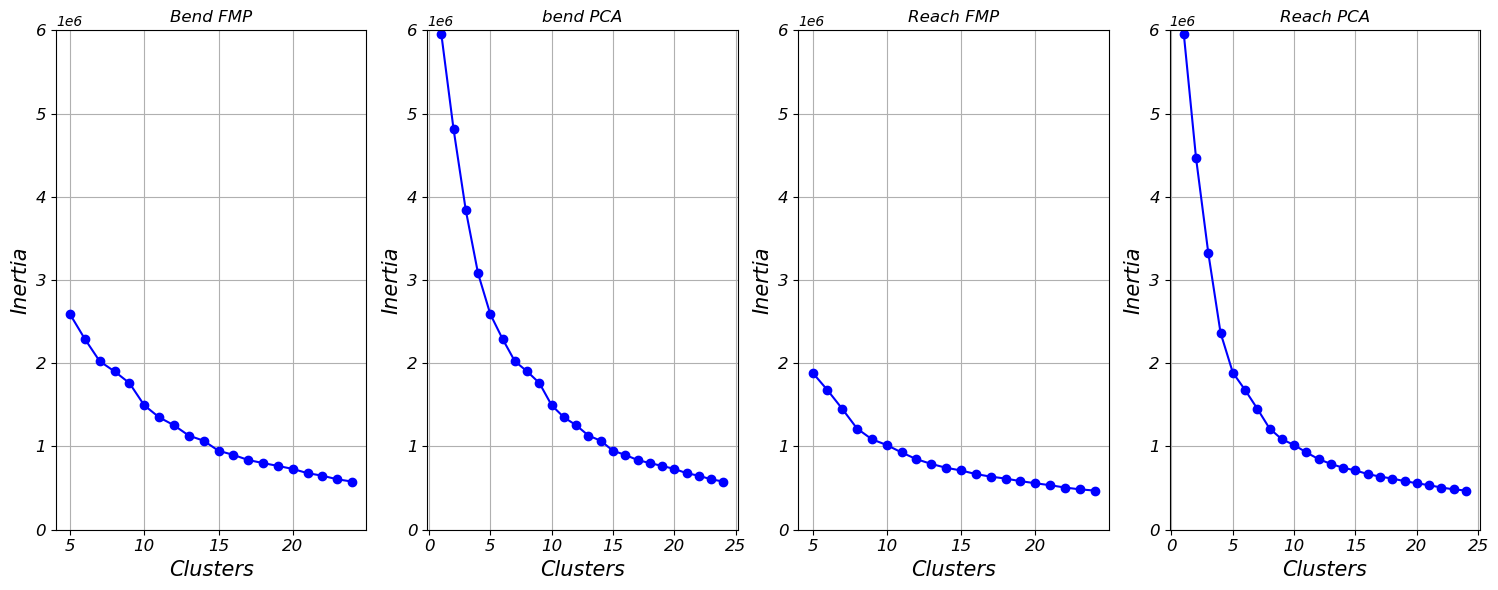

In [147]:
f, ax = plt.subplots(ncols = 4, figsize = [15,6], squeeze = False)
titles = ['Bend FMP', 'bend PCA', 'Reach FMP', 'Reach PCA']
for i in range(4):
    K  = krL[i]
    IN = inL[i]
    for I in IN:
        if (i == 0) | (i == 2):
            K = K[4:]
            I = I[4:]
        ax[0,i].plot(K, I, marker = 'o', color = 'blue')
        ax[0,i].grid()
        ax[0,i].tick_params(axis='both', which='major', labelsize=tickSize)
        ax[0,i].set_xlabel('Clusters', fontsize = labelSize)
        ax[0,i].set_ylabel('Inertia' , fontsize = labelSize)
        ax[0,i].set_title(titles[i])
        ax[0,i].set_ylim([0,6e6])
plt.tight_layout()
plt.show()

## Silhouette score
Apply on smaller number of centroids since it is computationally expensive

In [181]:
def resampleSilhouette(algo, X, sampleSize,random_state =42, printScore = False):

    labels             = algo.fit_predict(X)
    if X.shape[0] < sampleSize:
        sampleSize = X.shape[0]
    lab, labCounts = np.unique(labels,return_counts=True)
    # print(labCounts)
    if all(labCounts>10):
        # print(X, labels)
        X_sample, y_sample = resample(X, labels, n_samples=sampleSize, random_state=random_state)
        silScore           = silhouette_score(X_sample, y_sample)
        davScore           = davies_bouldin_score(X_sample, y_sample)
    else:
        silScore, davScore = np.nan, np.nan
    if printScore == True:
        print(f"Silhouette Score (sample size-{sampleSize}, random_state-{random_state}):", np.round(silScore,3), np.round(davScore, 3))
    return silScore, davScore

In [6]:
import numpy as np

A = np.array([0,0,1,1,3,3,4,4])
_, B = np.unique(A, return_counts=True)

np.nanmean([np.nan,np.nan])

/tmp/ipykernel_158406/2712792804.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean([np.nan,np.nan])


nan

In [185]:

sampleSize = 50000
clusters = [3,4,5, 6,7,8 ,9,10,11,12, 13, 14, 15, 20, 30]
# clusters = [3]
vars = [X_bend_scaled, dfBendCluster[pcaBendCols[0:1]], X_reach_scaled, dfReachCluster[pcaReachCols]]
varScoreSil, varScoreDav = [], []
for var in vars:
    silScore, davScore = [], []
    for i,c in enumerate(clusters):
        print(c)
        sL, dL = [], []
        for rs in [43, 50 ,60]:
            kmeans = KMeans(n_clusters=c,init='k-means++',random_state=rs)
            

            s, d = resampleSilhouette(kmeans, var  , sampleSize, rs,False)
            sL.append(s)
            dL.append(d)
        
        silScore.append(np.mean(sL))
        davScore.append(np.mean(dL))
        # print(sL, s, silScore)
        print(f"Silhouette Score (sample size-{sampleSize}, random_state-{rs}):", np.round(silScore[i],15), np.round(davScore[i], 15))
    varScoreSil.append(silScore)
    varScoreDav.append(davScore)
    print()

3
Silhouette Score (sample size-50000, random_state-60): 0.731876776204088 0.805949294816057
4
Silhouette Score (sample size-50000, random_state-60): 0.608966044597722 0.765552396618688
5
Silhouette Score (sample size-50000, random_state-60): 0.557774982597755 0.777195280741393
6
Silhouette Score (sample size-50000, random_state-60): 0.511544775309122 0.74879899734522
7
Silhouette Score (sample size-50000, random_state-60): 0.481205985871915 0.766653334156242
8
Silhouette Score (sample size-50000, random_state-60): 0.503303399550323 0.646982889885603
9
Silhouette Score (sample size-50000, random_state-60): 0.477444974568664 0.673945265829924
10
Silhouette Score (sample size-50000, random_state-60): 0.466153943932258 0.670026423603788
11
Silhouette Score (sample size-50000, random_state-60): 0.467876106639614 0.656880808364032
12
Silhouette Score (sample size-50000, random_state-60): 0.425501323566038 0.668939738328953
13
Silhouette Score (sample size-50000, random_state-60): nan nan
14

In [1]:
# plt.plot(clusters, davScore, marker = 'o', color = 'blue', label = 'Davies Bouldin')
# plt.plot(clusters, silScore, marker = 'o', color = 'red', label = 'Silhouette')
# plt.yticks(np.arange(0.2,1.4,0.1))
# plt.legend()
# plt.show()

## Cluster distribution

In [217]:
com = [1,2,3]
clusters = [1,2,3]
scores = []

In [ ]:
for j,c in enumerate(clusters):
    scores.append([c, np.mean(com), np.mean(clusters)])

In [218]:
clusters = [3,4,8]

In [222]:
def add_labels(df,cols, clusters):

    kmeans = KMeans(n_clusters=clusters,init='k-means++',random_state=42)
    df[f'KMeans_pca_{clusters}']=  kmeans.fit_predict(df[cols])
    return df
for i in clusters:
    dfBendCluster = add_labels(dfBendCluster  , pcaBendCols , i)
    dfReachCluster = add_labels(dfReachCluster, pcaReachCols, i)

    dfReachClusterLog = add_labels(dfReachClusterLog, pcaReachColsLog, i)

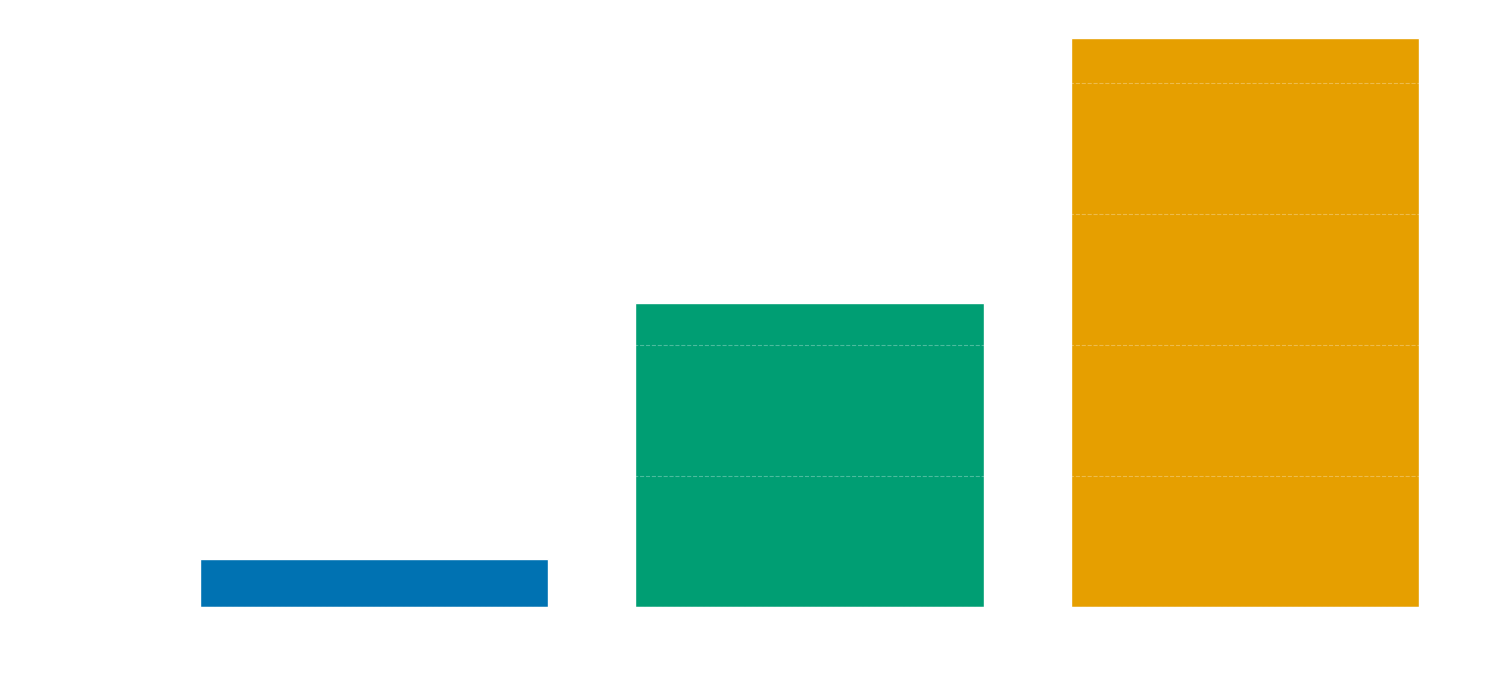

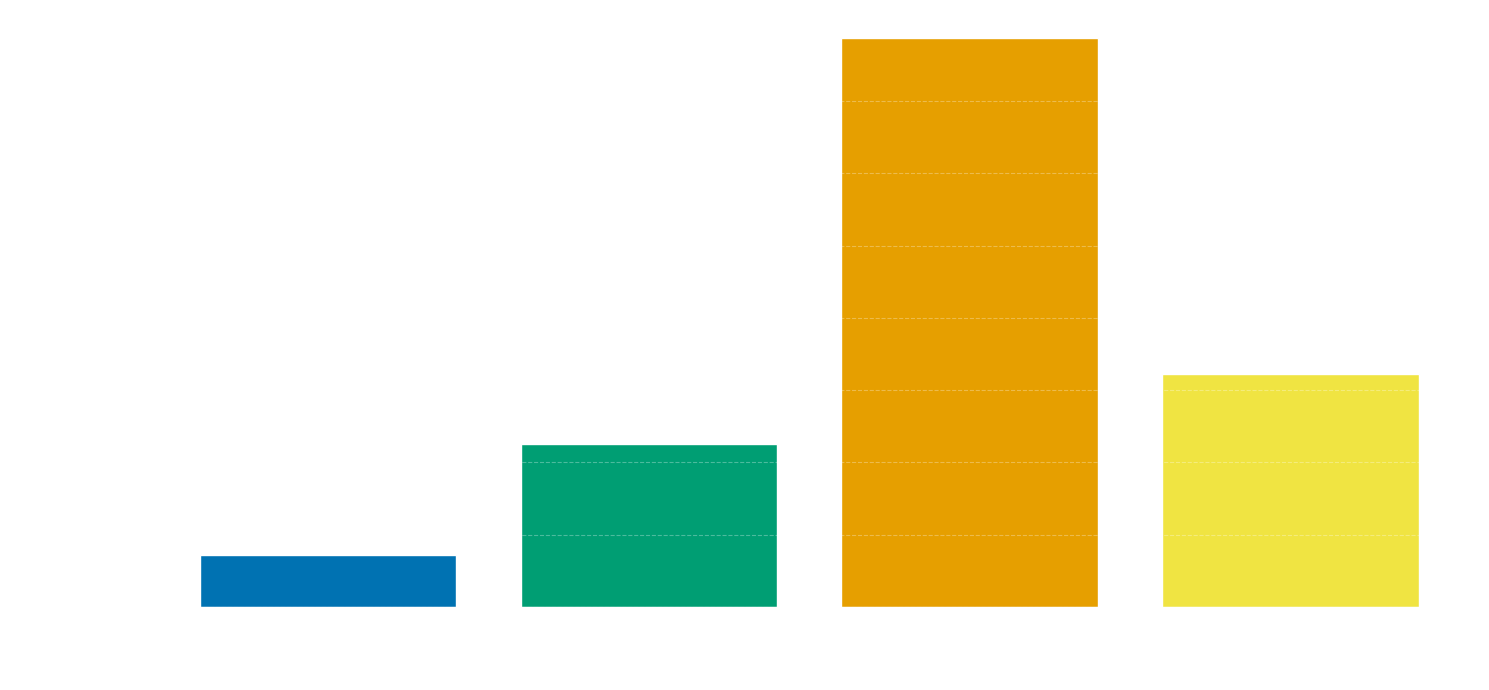

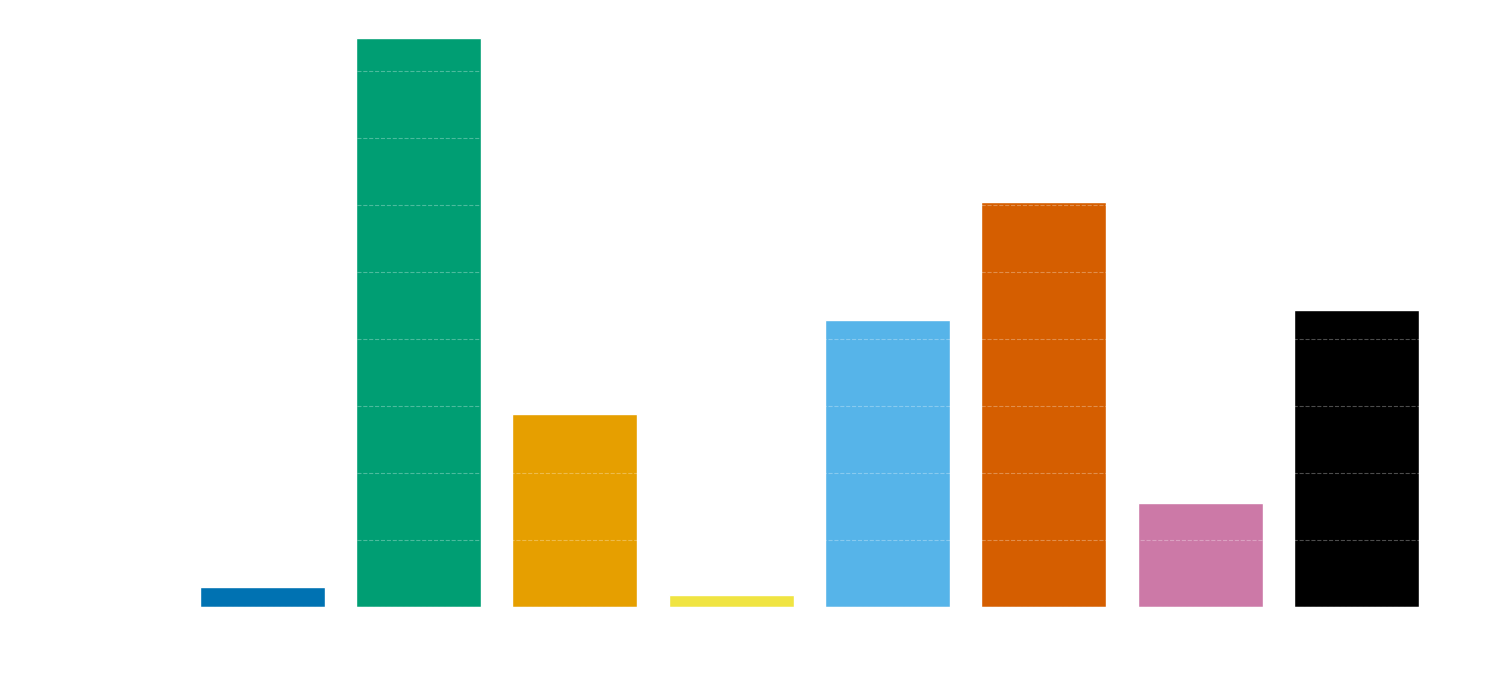

In [201]:
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_3', [''], 'Reach')
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_4', [''], 'Reach')
# bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_8', [''], 'Reach')
# bar_cluster_distribution_plot(dfReachClusterLog,'KMeans_pca_4', [''], 'Reach')
bar_cluster_distribution_plot(dfReachCluster,'kmeans_8', [''], 'Reach')
# bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_8', [''], 'Reach')
# bar_cluster_distribution_plot(dfBendCluster, 'KMeans_pca_5', [''], 'Bend')
# bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_6', [''])
# bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_7', [''])
# bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_8', [''])


## KDE per cluster

In [188]:
dfBendCluster[dfBendCluster['bendWidthRatio']< 0.9].shape[0]

108650

<Axes: xlabel='PCA1', ylabel='Density'>

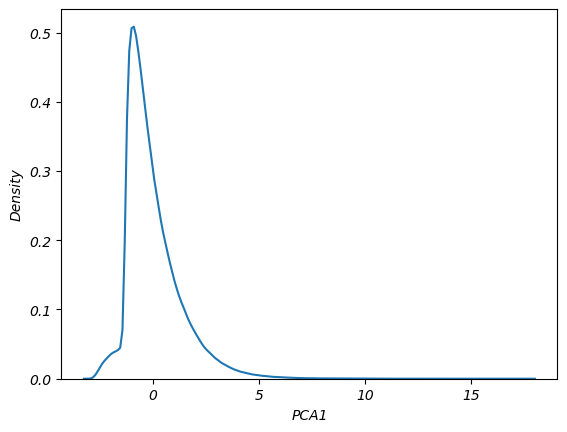

In [192]:
sns.kdeplot(data = dfBendCluster, x ='PCA1')


<Axes: xlabel='PCA2', ylabel='Density'>

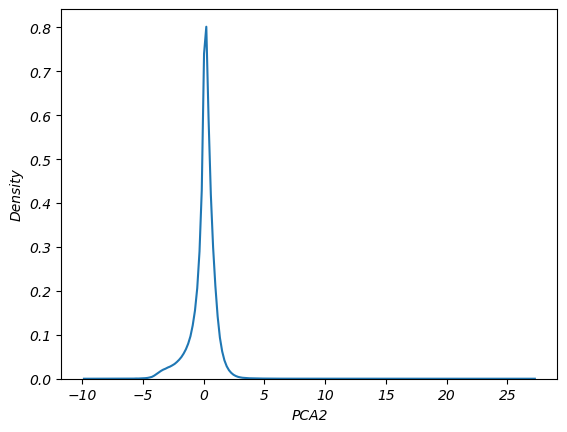

In [193]:
sns.kdeplot(data = dfBendCluster, x ='PCA2')

<Axes: xlabel='PCA3', ylabel='Density'>

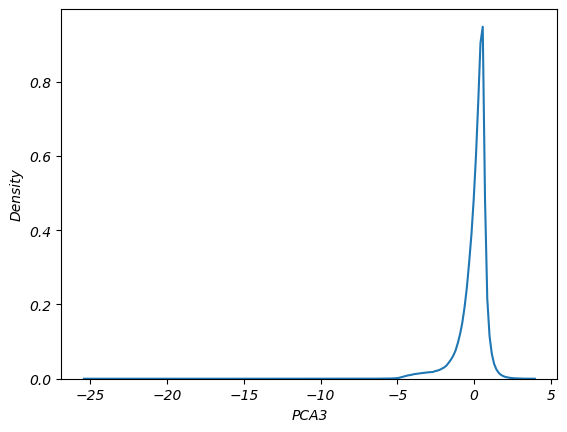

In [194]:
sns.kdeplot(data = dfBendCluster, x ='PCA3')

<Axes: xlabel='PCA1', ylabel='Density'>

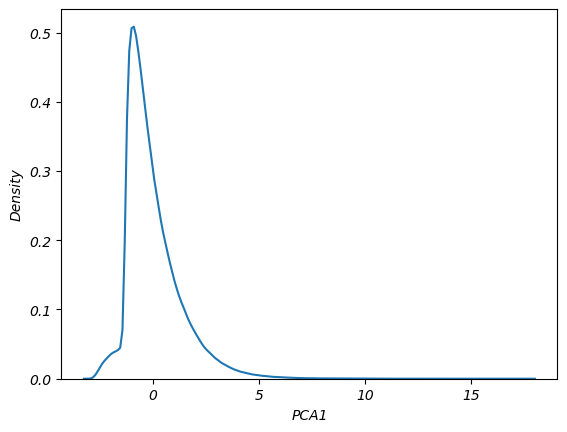

In [195]:
sns.kdeplot(data = dfBendCluster, x ='PCA1')

<Axes: xlabel='bendSin', ylabel='Density'>

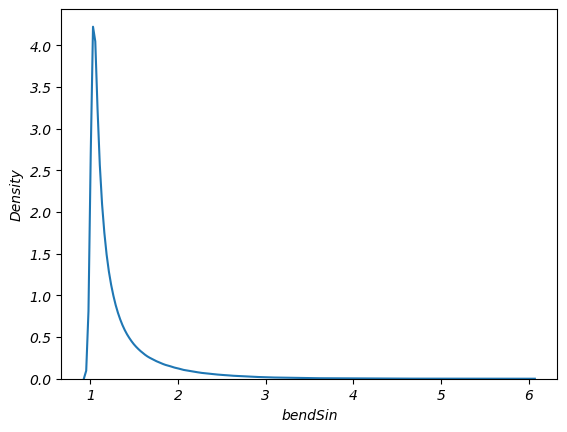

In [189]:
sns.kdeplot(data = dfBendCluster, x ='bendSin')

<Axes: xlabel='bendAng', ylabel='Density'>

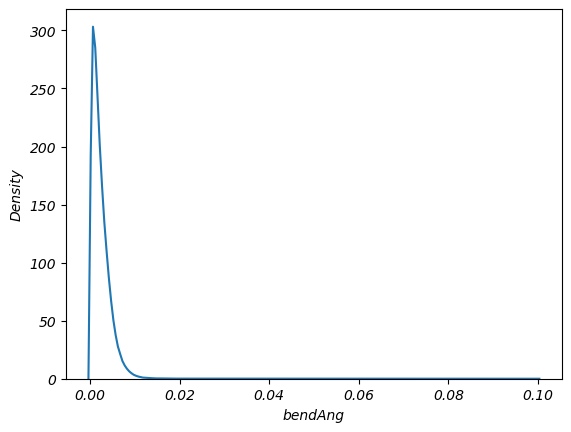

In [190]:
sns.kdeplot(data = dfBendCluster, x ='bendAng')

<Axes: xlabel='dimApex', ylabel='Density'>

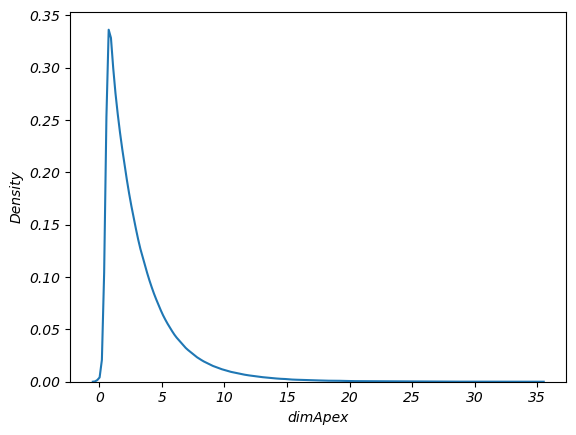

In [191]:
sns.kdeplot(data = dfBendCluster, x ='dimApex')

<Axes: xlabel='bendWidthRatio', ylabel='Density'>

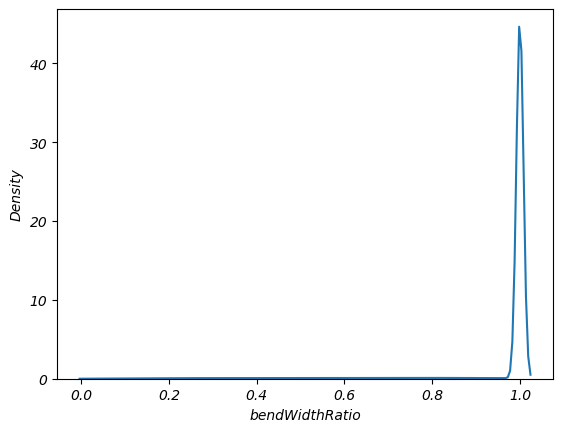

In [185]:
sns.kdeplot(data = dfBendCluster, x ='bendWidthRatio')

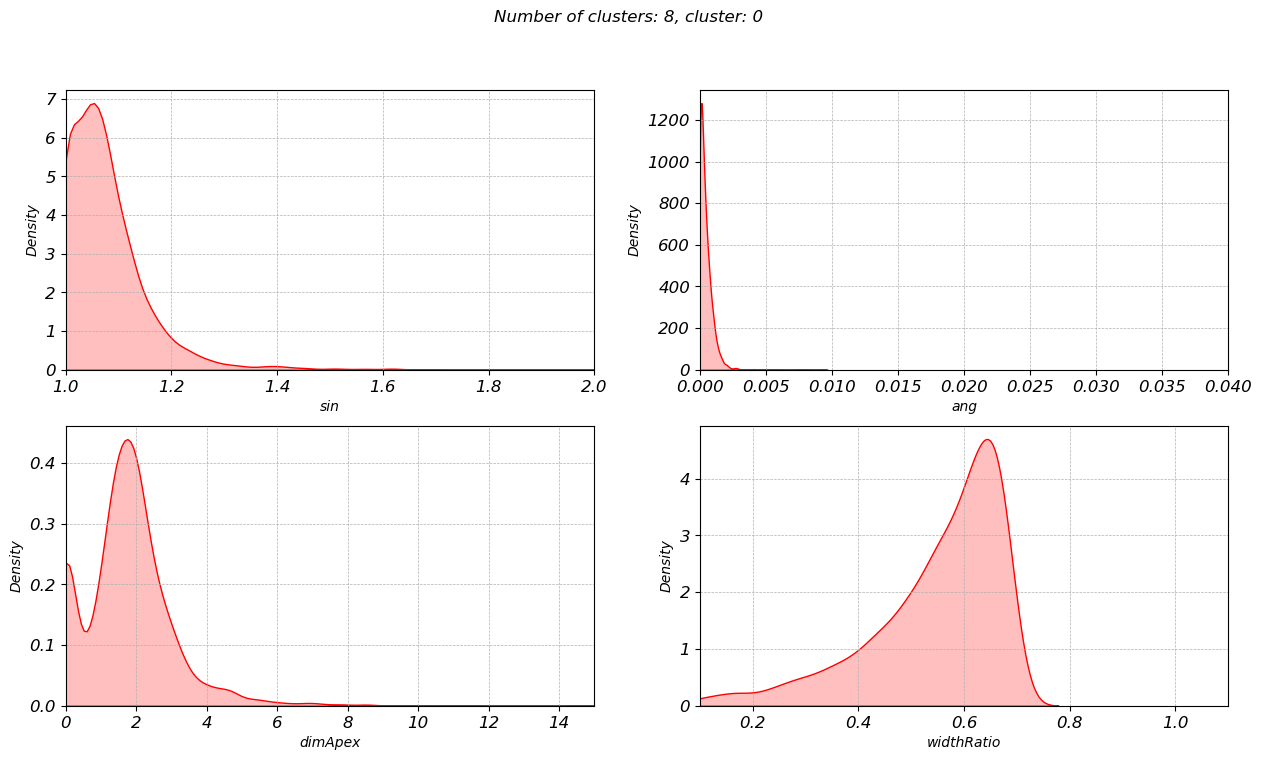

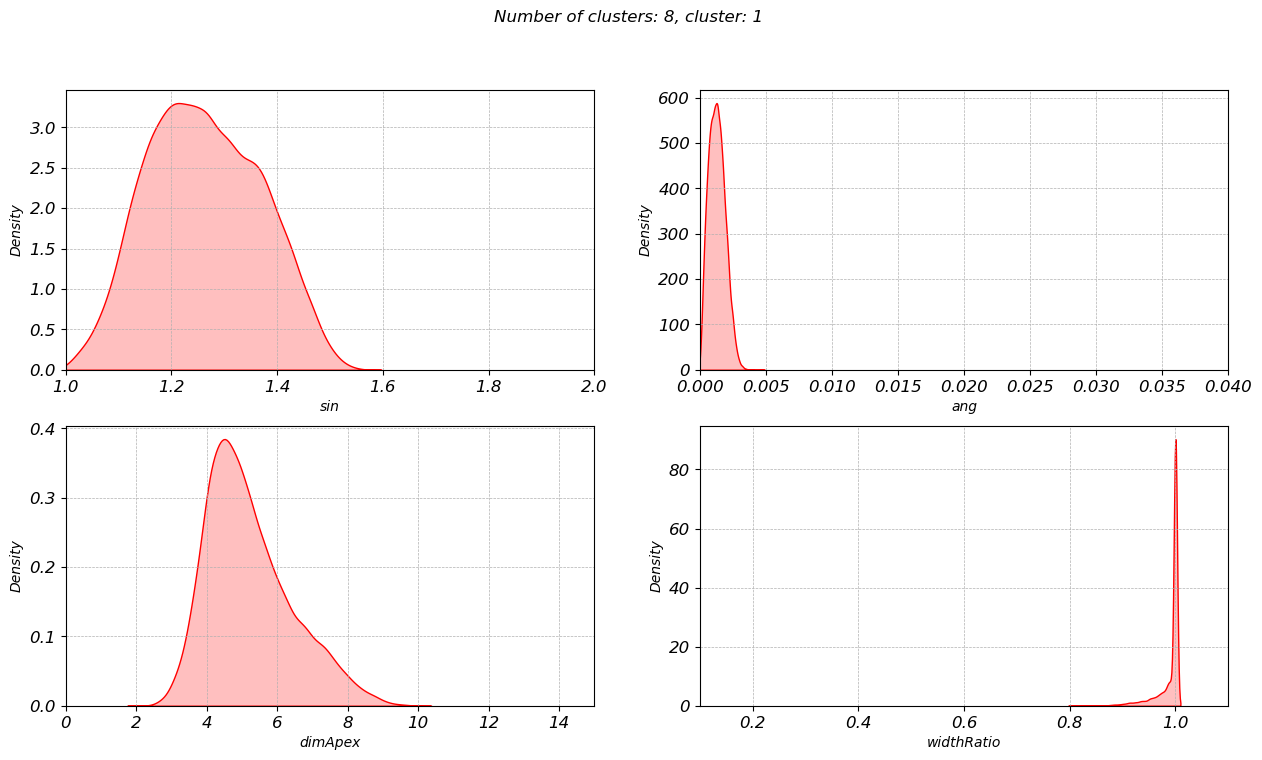

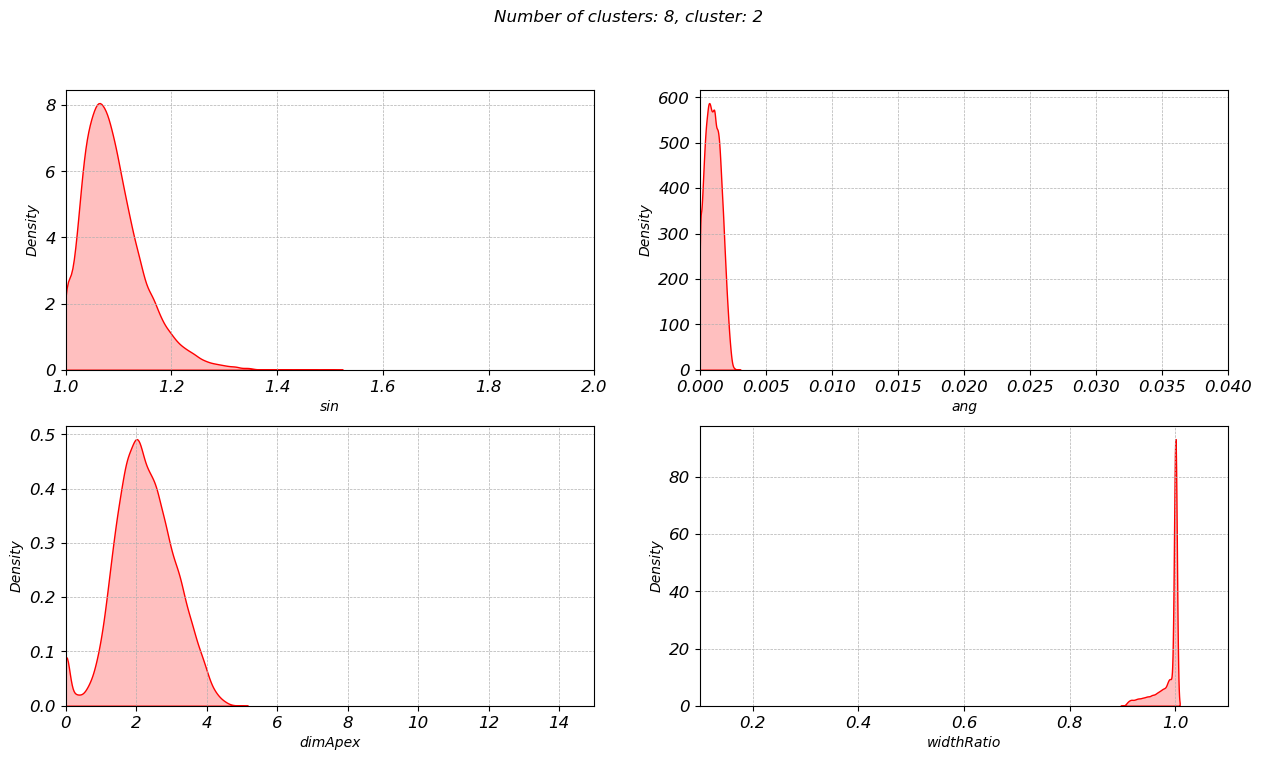

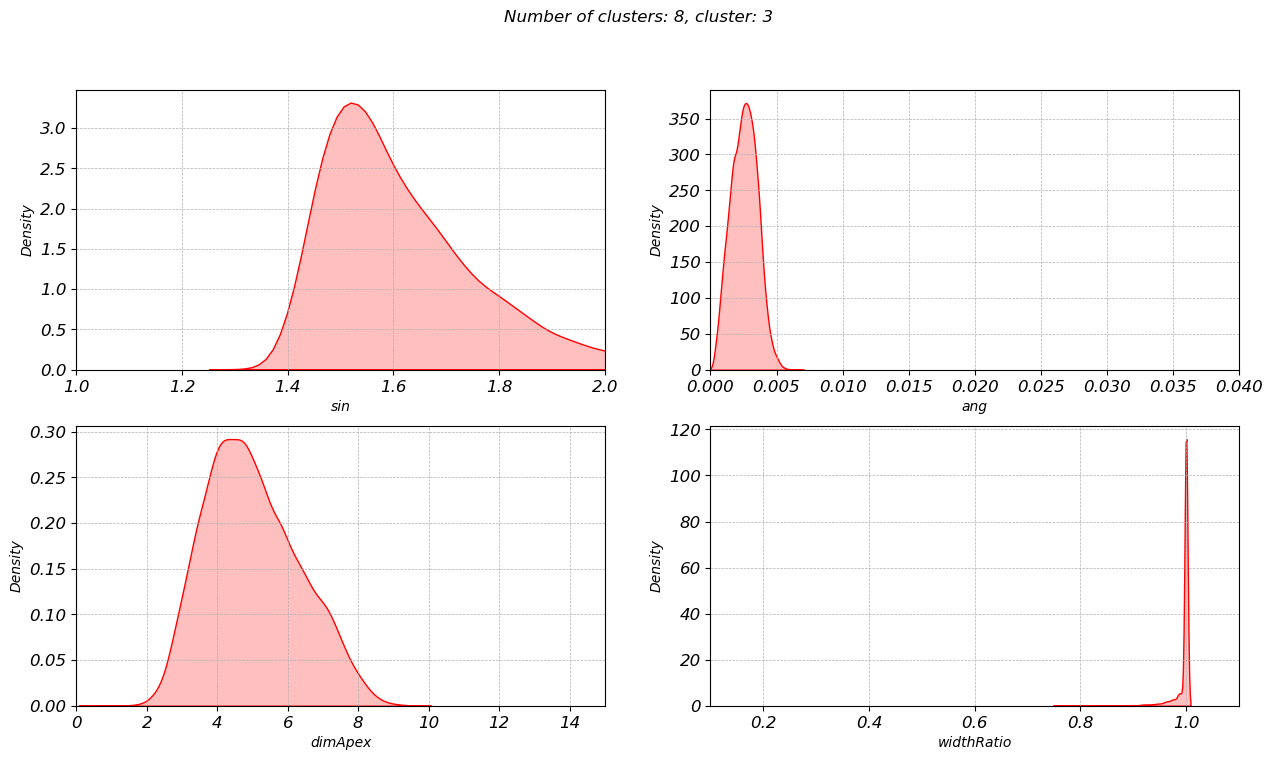

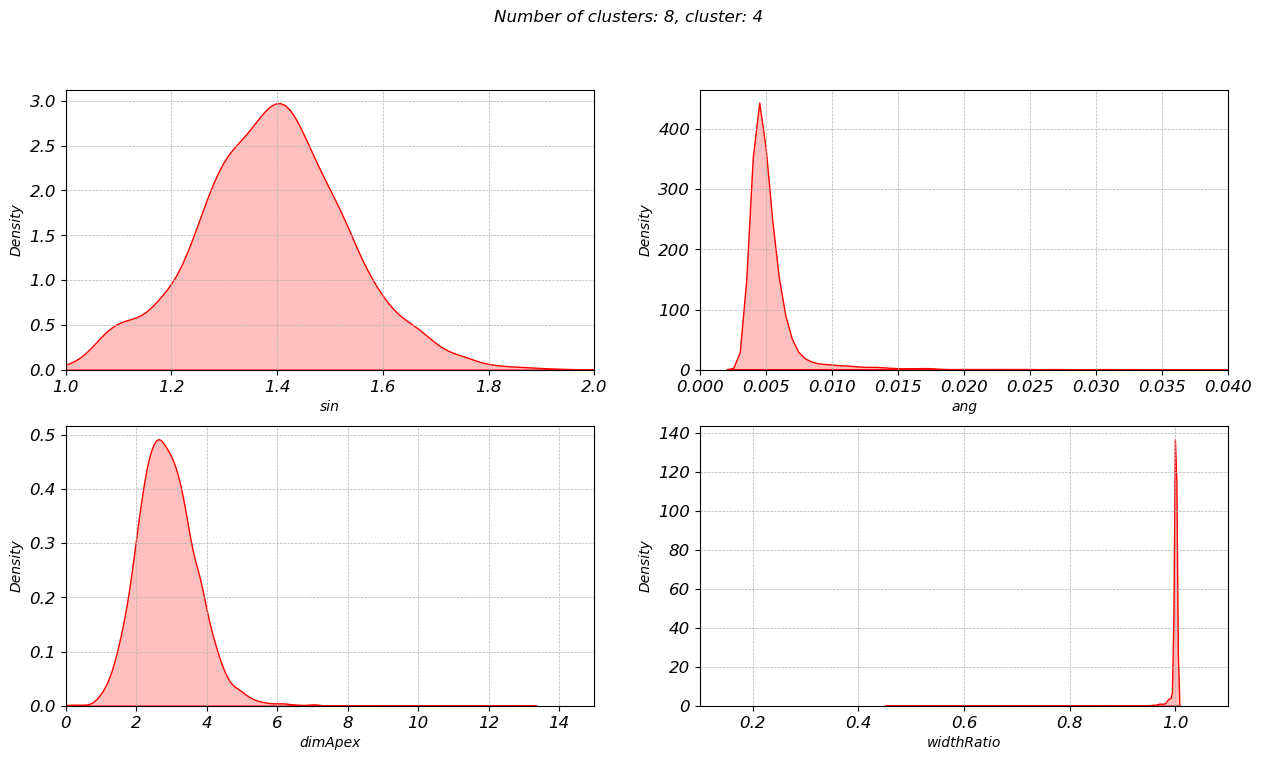

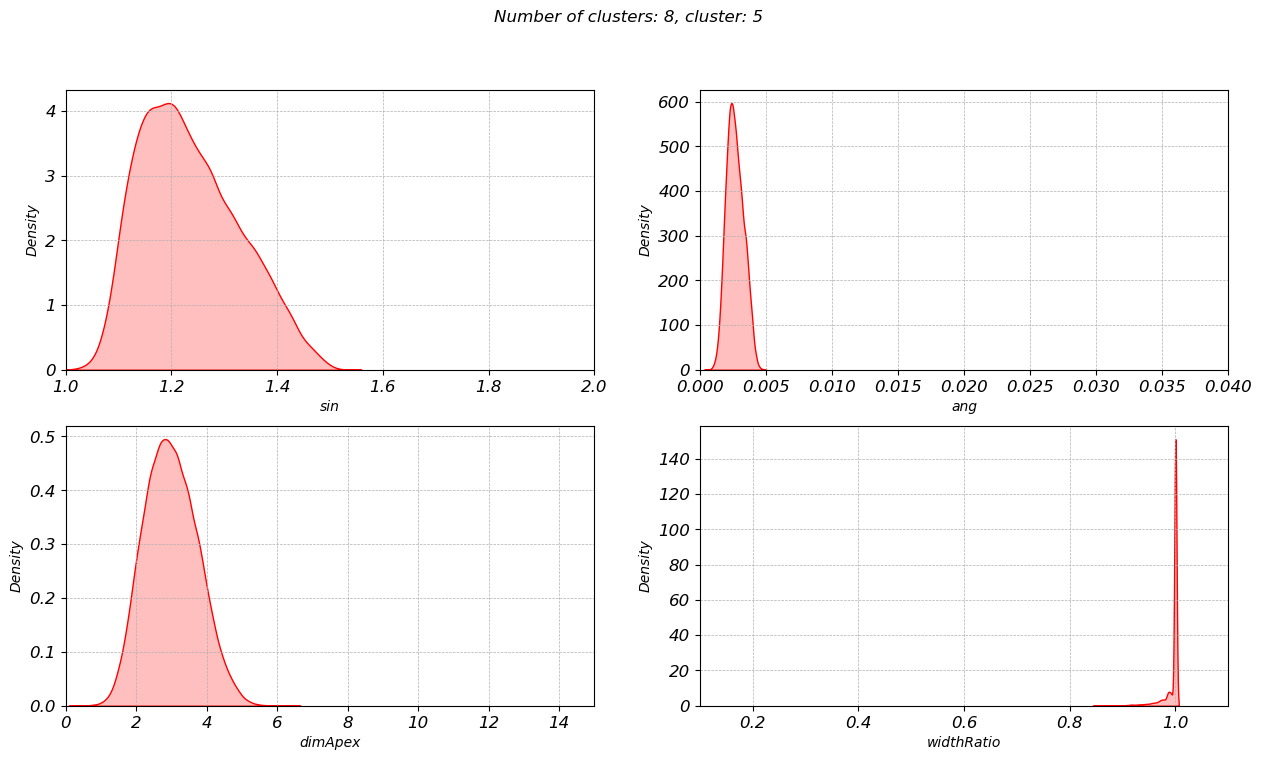

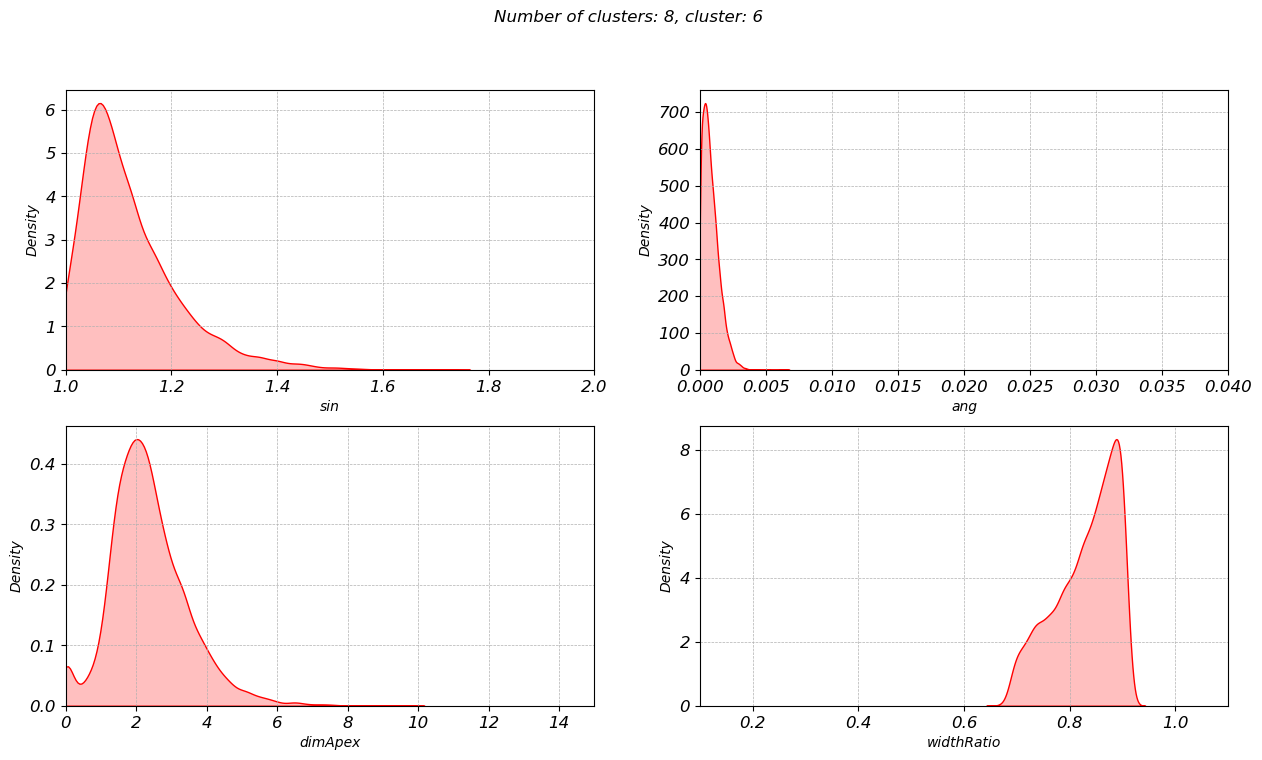

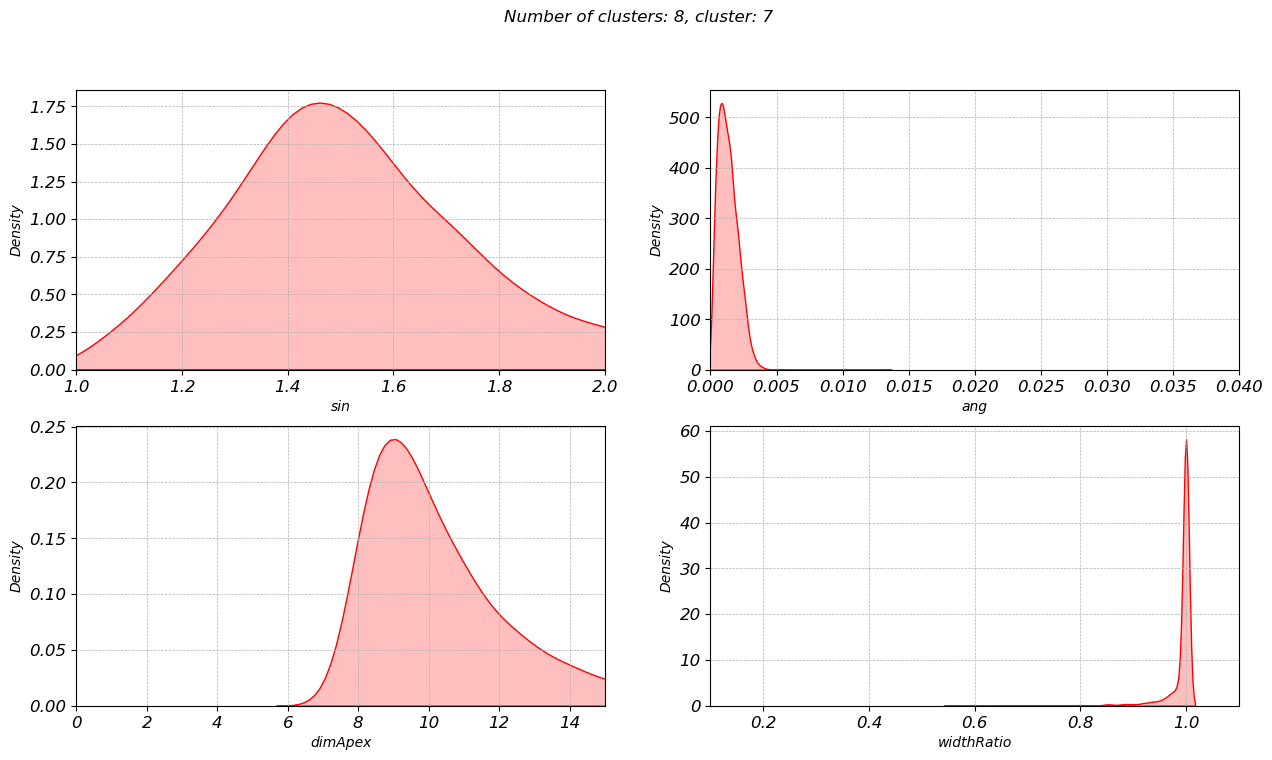

In [183]:
plot_kde_cluster(dfReachCluster, ['sin','ang', 'dimApex' , 'widthRatio'], 'KMeans_pca_8', 8)

## KDE var vs var

In [229]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


In [231]:
def apply_kde(df, cluster, maxCluster, comb):

    dfF = df.loc[df[f'KMeans_pca_{maxCluster}'] == cluster]
    x = dfF[comb[0]].values
    y = dfF[comb[1]].values

    # Compute 2D KDE
    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    # Evaluate on a grid
    xmin, xmax = x.min()-1, x.max()+1
    ymin, ymax = y.min()-1, y.max()+1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200),
                    np.linspace(ymin, ymax, 200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions), X.shape)

    # Minimum density threshold
    min_density = 0.0001  # skip contours below this


    # Mask low densities
    # Z_masked = np.where(Z < min_density, np.nan, Z)
    # print(Z_masked)
    return X, Y, Z


In [232]:
cols = ['sin', 'ang', 'dimApex', 'widthRatio']
combs = list(itertools.combinations(cols,2))
clusters = 8
kde_list = []
for comb in combs:
    k = []
    for c in range(clusters):
        k.append(apply_kde(dfReachCluster, c, clusters, comb))
    kde_list.append(k)

In [233]:
C = [combs[2]]
C1 = [kde_list[2]]

('sin', 'widthRatio')
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]
[1, 1.6] [0.5, 1.1]


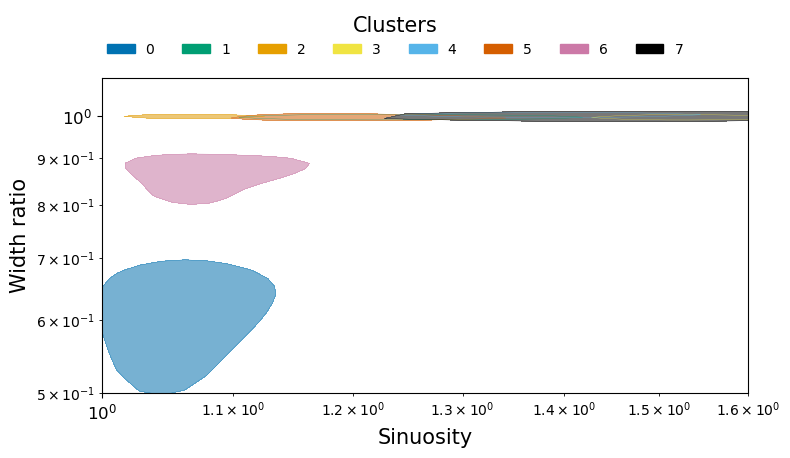

In [239]:
axisRange = {'sin':       [1, 1.6],
             'ang':       [-0.001, 0.01],
             'dimApex':   [0, 7.5],
             'widthRatio':[0.5, 1.1]}

axisLabels = {'sin':        'Sinuosity',
              'ang':        'Curvature',
              'dimApex':    'Dim. amplitude',
              'widthRatio': 'Width ratio'}

colors = ['#0072B2', '#009E73', '#E69F00', '#F0E442', '#56B4E9', '#D55E00', '#CC79A7', '#000000']

f, ax = plt.subplots(ncols=1, nrows=1, figsize=[8, 4])
f.patch.set_alpha(0)           # transparent figure background
# ax.set_facecolor('none')       # transparent axes background

comb = C[0]
print(comb)
for c in range(clusters):
    X, Y, Z = C1[0][c]
    Z_min = np.nanmin(Z)
    Z_max = np.nanmax(Z)
    n_levels = 3
    levels = np.linspace(Z_min, Z_max, n_levels)
    if all(levels == 0):
        continue

    cmap = sns.light_palette(colors[c], as_cmap=True)
    cf = ax.contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha=1)
    cs = ax.contour(X, Y, Z, levels=levels[1:], colors=colors[c], linewidths=0.2)

    print(axisRange[comb[0]], axisRange[comb[1]])
    ax.set_xlim(axisRange[comb[0]])
    ax.set_ylim(axisRange[comb[1]])
    ax.set_xlabel(axisLabels[comb[0]], fontsize=labelSize, color='black')
    ax.set_ylabel(axisLabels[comb[1]], fontsize=labelSize, color='black')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=tickSize, colors='black')

legend_colors = colors
handles = [Patch(color=legend_colors[i], label=group) for i, group in enumerate(np.arange(len(legend_colors)))]

lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=8,
    frameon=False,
    title='Clusters',
    title_fontsize=labelSize
)
plt.setp(lgd.get_texts(), color='black')
lgd.get_title().set_color('black')

plt.tight_layout()
save_dir = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/Congres/AGU_2025/presentation/analysis/'
plt.savefig(
    save_dir + 'morphology_clustering_3.svg',
    bbox_extra_artists=(lgd,),
    bbox_inches='tight',
    dpi=2000,
    facecolor='black',   # transparent output
    edgecolor='black'
)
plt.show()


In [ ]:
axisRange = {'sin':       [1,1.6],
             'ang':       [-0.001,0.01],
             'dimApex':   [0,7.5],
             'widthRatio':[0.7,1.1]}

axisLabels = {'sin':       'Sinuosity',
             'ang':       'Curvature',
             'dimApex':   'Dim. amplitude',
             'widthRatio': 'Width ratio'}

colors = ['blue', 'green', 'red', 'gray', 'purple', 'cyan', 'yellow', 'orange']
colors = ['#0072B2',  '#009E73', '#E69F00', '#F0E442','#56B4E9', '#D55E00', '#CC79A7', '#000000']
# f,ax = plt.subplots(ncols = 2, nrows = 3, figsize = [12,12])
f,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [12,4])
# ax = ax.flatten()
for i, comb in enumerate(C):
    print(comb)
    for c in range(clusters):
        X, Y, Z = C1[i][c]
        # X, Y, Z = kde_list[i][c]
        # Define contour levels ABOVE min_density
        Z_min = np.nanmin(Z)
        Z_max = np.nanmax(Z)
        n_levels = 3
        levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
        if all(levels == 0):
            continue
        # print(c, levels)
        # Filled contours (shades of one color)
        cmap = sns.light_palette(colors[c], as_cmap=True)
        cf = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.8)

        # Contour lines (single color, skip lowest)
        cs = ax[i].contour(X, Y, Z, levels=levels[1:], colors=colors[c], linewidths=0.2)
        print(axisRange[comb[0]], axisRange[comb[1]])
        ax[i].set_xlim(axisRange[comb[0]])
        ax[i].set_ylim(axisRange[comb[1]])
        ax[i].set_xlabel(axisLabels[comb[0]], fontsize = labelSize)
        ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
        ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
        # Scatter original points
        # ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

        # Axes and grid
        # ax.set_facecolor("white")
        # ax.grid(True, linestyle="--", alpha=0.5)

        # Colorbar
        # fig.colorbar(cf, ax=ax, label="Density")

# Create legend handles manually (to ensure one instance of each label)
colors = colors[0:3]
handles = [Patch(color=colors[i], label=group) for i, group in enumerate(np.arange(len(colors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=8,
    frameon=False,
    title = 'Clusters',
    title_fontsize = labelSize
)
plt.tight_layout()
# plt.savefig(directory + 'results/figures/morphology_clustering_8.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 2000)
plt.show()

In [166]:
gdf[('n_chan_max' > 0) & ('widthRatio' == 1)]

TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:

# Define contour levels ABOVE min_density
Z_min = np.nanmin(Z_masked)
Z_max = np.nanmax(Z_masked)


n_levels = 5
levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density

# Plot
sns.set_theme()
fig, ax = plt.subplots(figsize=(6,5))

# Filled contours (shades of one color)
cmap = sns.light_palette("blue", as_cmap=True)
cf = ax.contourf(X, Y, Z_masked, levels=levels, cmap=cmap)

# Contour lines (single color, skip lowest)
cs = ax.contour(X, Y, Z_masked, levels=levels[1:], colors='black', linewidths=1)

# Scatter original points
ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

# Axes and grid
ax.set_facecolor("white")
ax.grid(True, linestyle="--", alpha=0.5)

# Colorbar
fig.colorbar(cf, ax=ax, label="Density")

plt.show()


Linear relationship between axis (sin, ang): 0
3.9640783191874795e+21

Linear relationship between axis (sin, ang): 1
1.0618950026948766e+19

Linear relationship between axis (sin, ang): 2
1.6380992320846477e+18

Linear relationship between axis (ang, dimApex): 0
2.0489421890412397e+19

Linear relationship between axis (ang, dimApex): 1
9.3644205325095e+16

Linear relationship between axis (ang, dimApex): 2
1.1469398860628152e+16

Linear relationship between axis (ang, widthRatio): 0
1.7111998199123285e+21

Linear relationship between axis (ang, widthRatio): 1
1.0913367663717674e+20

Linear relationship between axis (ang, widthRatio): 2
1.3742487537833188e+20



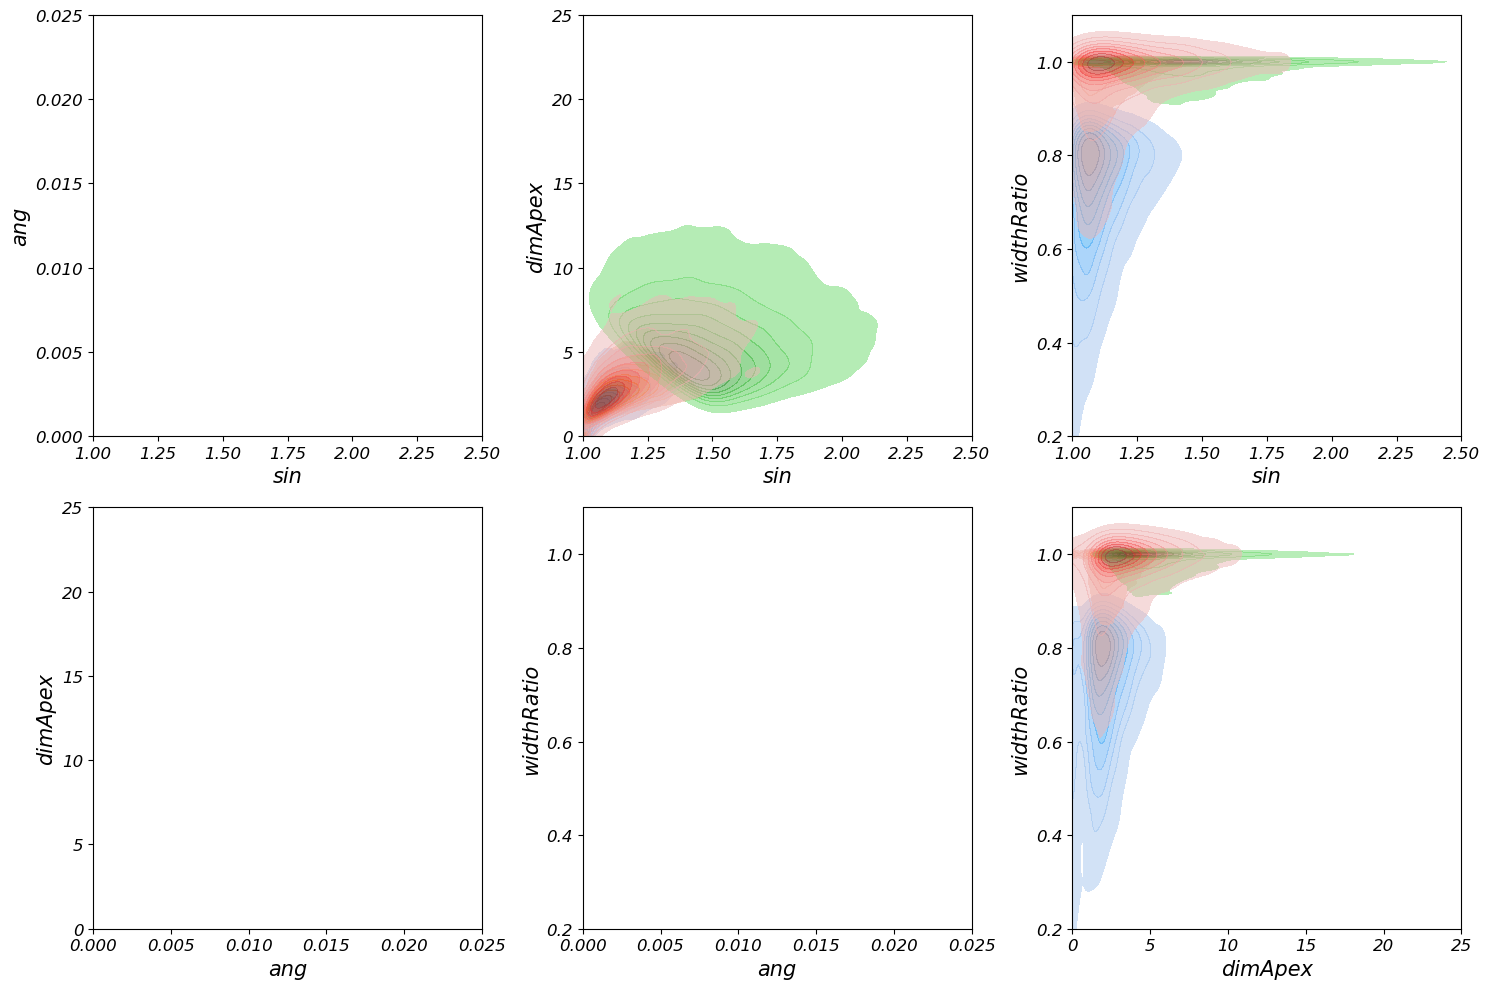

In [149]:
def plotKDE(df,clusterCol,cols, axisRange):
    plotComb = list(itertools.combinations(cols,2))

    unique_labels = sorted(df[clusterCol].dropna().unique())
    labels = []

    if len(plotComb) % 2:
        nrows, ncols = int(len(plotComb)/2), 2
    else:
        nrows, ncols = int(len(plotComb)/3), 3

    f, ax = plt.subplots(nrows=nrows, ncols = ncols, figsize = [15, 5*nrows])
    ax    = ax.flatten()

    for i, pc in enumerate(plotComb):
        XR = axisRange[pc[0]]
        for l, label in enumerate(unique_labels):
            label = int(label)
            subset = df[df[clusterCol] == label]
            
            kdeT = subset[[pc[0], pc[1]]].dropna().to_numpy()
            cov = np.cov(kdeT.T)

            if np.linalg.cond(cov) > 1e10:
                print(f'Linear relationship between axis ({pc[0]}, {pc[1]}): {label}')
                print(np.linalg.cond(cov))
                print()
            else:
                sns.kdeplot(
                    data=subset,
                    x=pc[0],
                    y=pc[1],
                    ax=ax[i],
                    # color=palette[i],
                    fill=True,
                    warn_singular=False,
                    alpha = 0.5
                )
                labels.append(label)


        # Plot limits and layout
        ax[i].set_xlim(axisRange[pc[0]])
        ax[i].set_ylim(axisRange[pc[1]])
        ax[i].set_xlabel(pc[0], fontsize = labelSize)
        ax[i].set_ylabel(pc[1], fontsize = labelSize)
        ax[i].tick_params(axis = 'both', which = 'major', labelsize = tickSize)
    plt.tight_layout()
    plt.show()

axisRange = {'sin': [1,2.5],
             'ang':[0,0.025],
             'dimApex': [0,25],
             'widthRatio':[0.2,1.1]}

plotKDE(dfReachCluster, 'KMeans_pca_4',['sin', 'ang', 'dimApex', 'widthRatio'], axisRange)

# GMM

In [221]:
def fit_GMM(df,c,cols, pca = True, max_iter = 100, n_init = 5, covariance_type = 'tied'):

    gmm = GaussianMixture(n_components=c, covariance_type=covariance_type, random_state=42, n_init = n_init, max_iter = max_iter, init_params='kmeans')#k-means++
    gmm.fit(df[cols])
    print('done Fitting')
    labelsHard = gmm.predict(df[cols])
    labelsSoft = gmm.predict_proba(df[cols])
    if pca == True:
        col = f'GMM_pca_{c}'
    else:
        col = f'GMM_{c}'
    df[f'{col}_hard'] = labelsHard

    for i in range(c):
        df[f'{col}_{i}_soft']=  labelsSoft[:,i]
    return df

def add_cluster_certainty(df,cluster, cert = [0.9,0.95,0.99]):
    cols_of_interest = [col for col in df.columns if f'_{cluster}_' in col  and col.endswith("_soft")]
    for t in cert:

        df.loc[df[cols_of_interest].max(axis=1) >= t, f'GMM_pca_{cluster}_{int(t*100)}'] = df[f'GMM_pca_{cluster}_hard']
    return df

In [222]:
clusters = 7

In [223]:
dfReachCluster = fit_GMM(dfReachCluster, clusters, pcaReachCols)
dfBendCluster  = fit_GMM(dfBendCluster , clusters, pcaBendCols)

done Fitting
done Fitting


In [224]:
dfReachCluster = add_cluster_certainty(dfReachCluster, clusters)
dfBendCluster  = add_cluster_certainty(dfBendCluster , clusters)

### Distribution

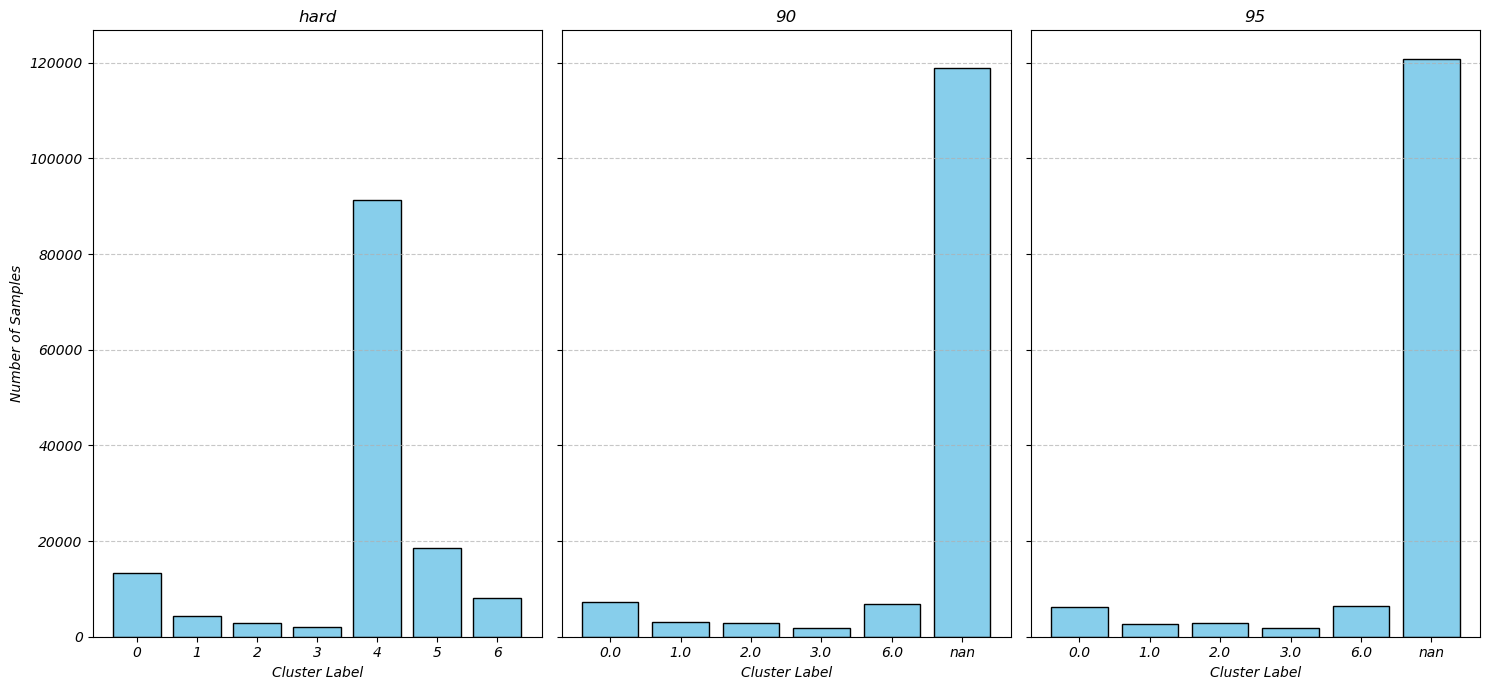

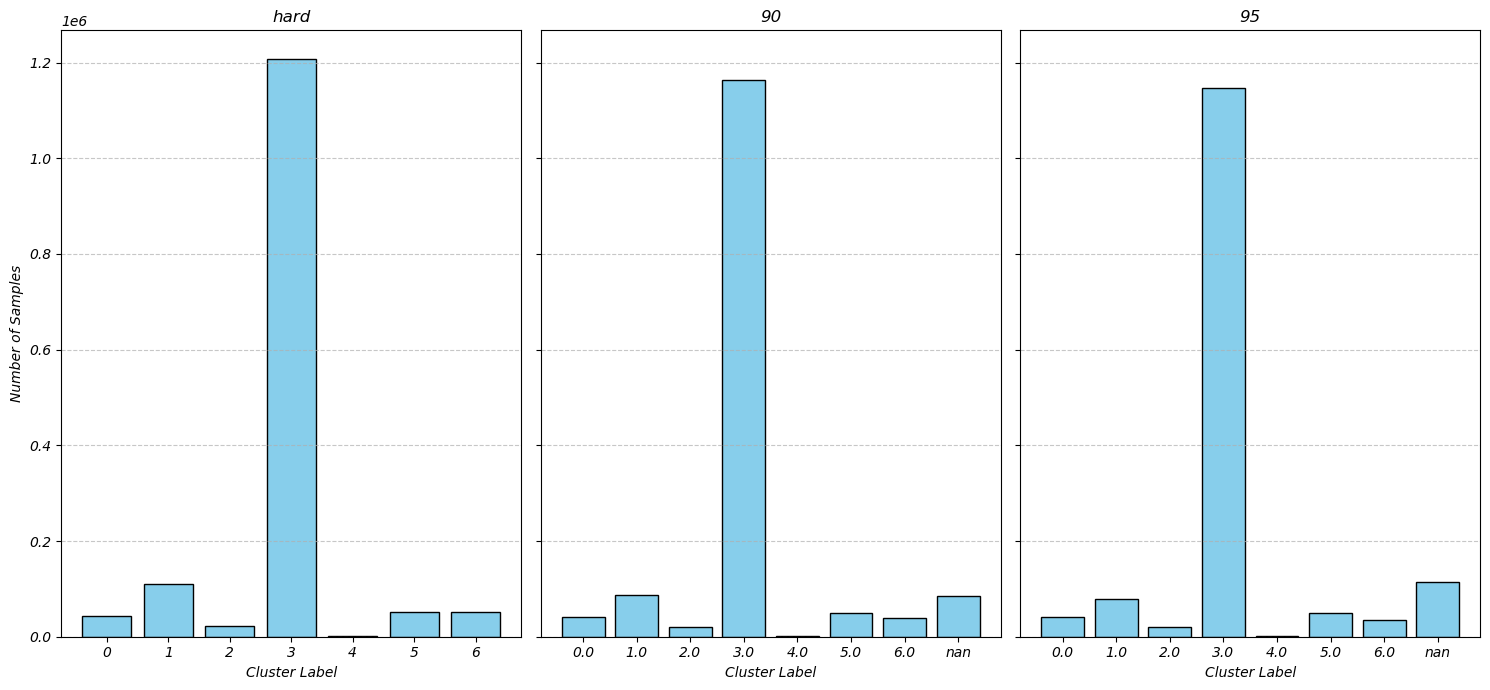

In [225]:
bar_cluster_distribution_plot(dfReachCluster,'GMM_pca_7', ['hard', '90', '95'])
bar_cluster_distribution_plot(dfBendCluster,'GMM_pca_7', ['hard', '90', '95'])

## KDE per cluster

In [31]:
cols = ['sin', 'ang', 'apex', 'widthRatio']
plotComb = list(itertools.combinations(cols, 2))

In [34]:
dfReachCluster[dfReachCluster['GMM_pca_7_hard'] == 2]['ang']

23187    0.037507
23188    0.037507
23189    0.037507
23190    0.037507
23191    0.037507
           ...   
69704    0.037507
70075    0.037507
70077    0.037507
70078    0.037507
70079    0.037507
Name: ang, Length: 4530, dtype: float64

/tmp/ipykernel_22598/1342897764.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  L = sns.kdeplot(data = data, x = cols[count], ax=axs[i,j], fill=True, color = 'red', legend = False)


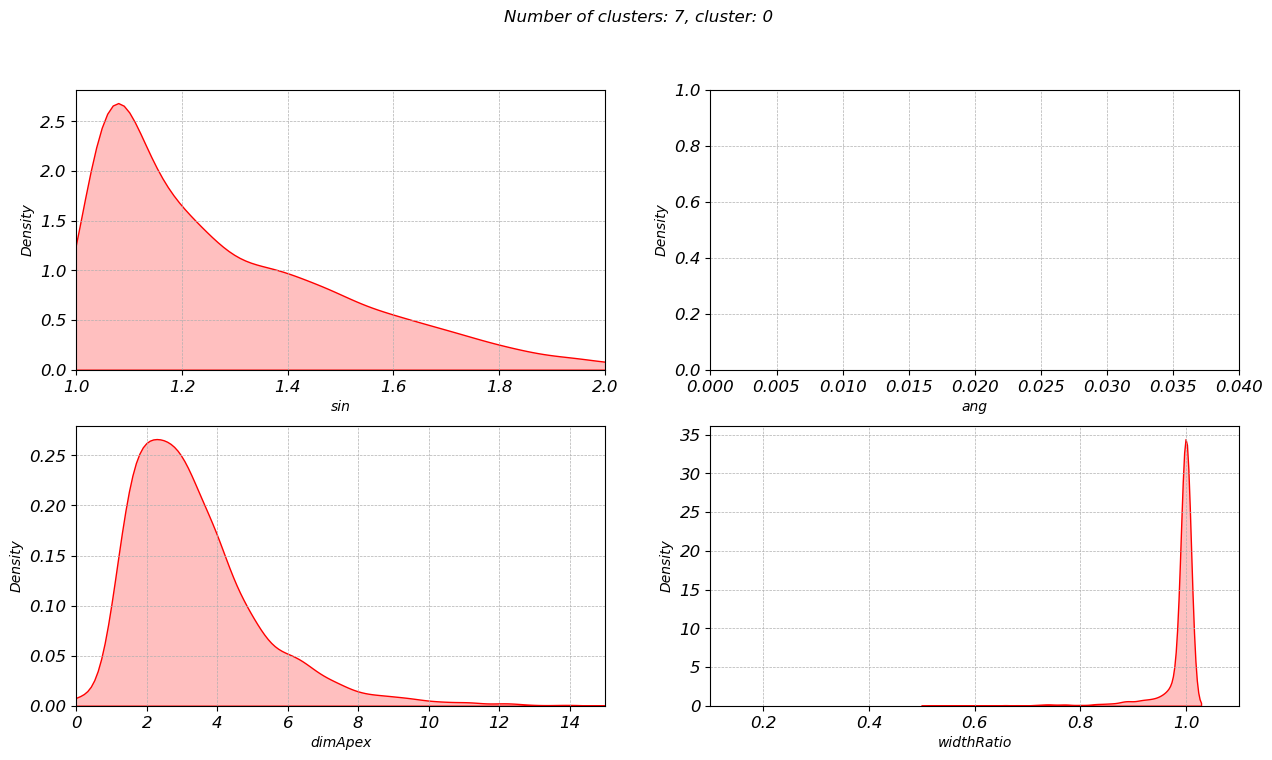

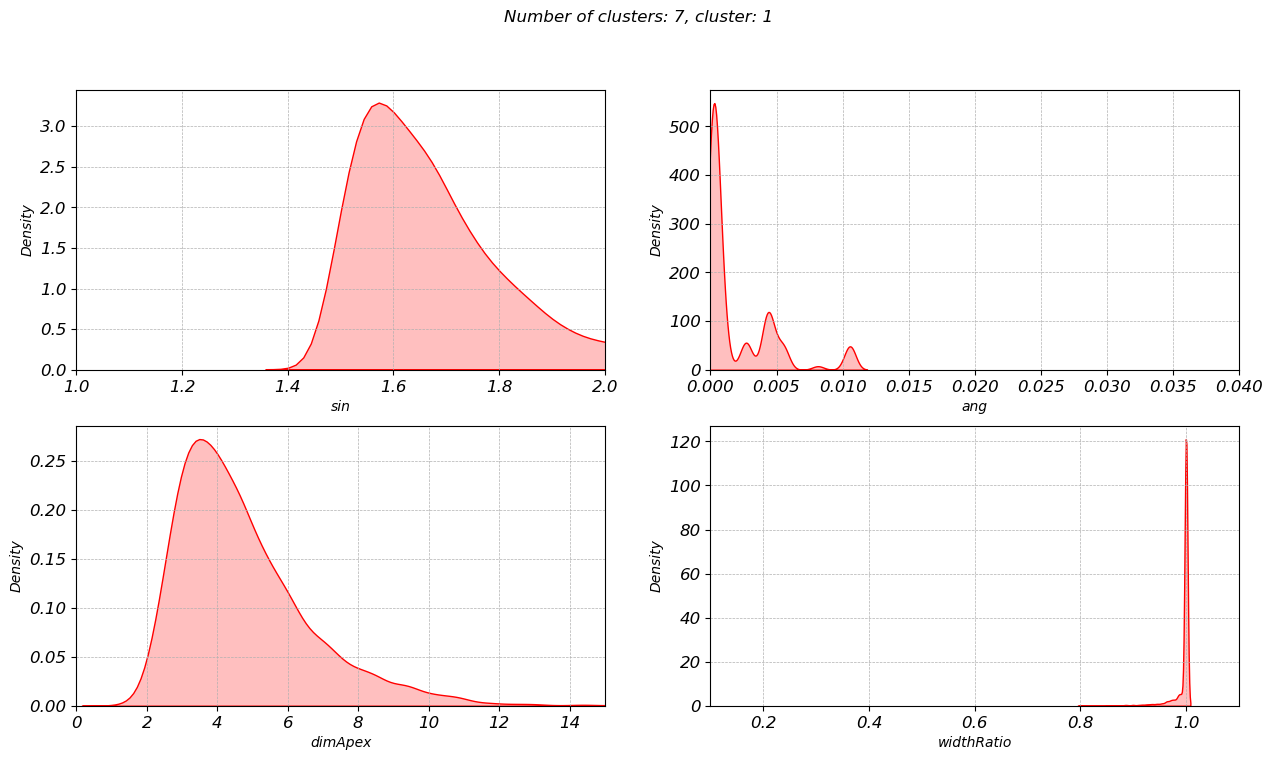

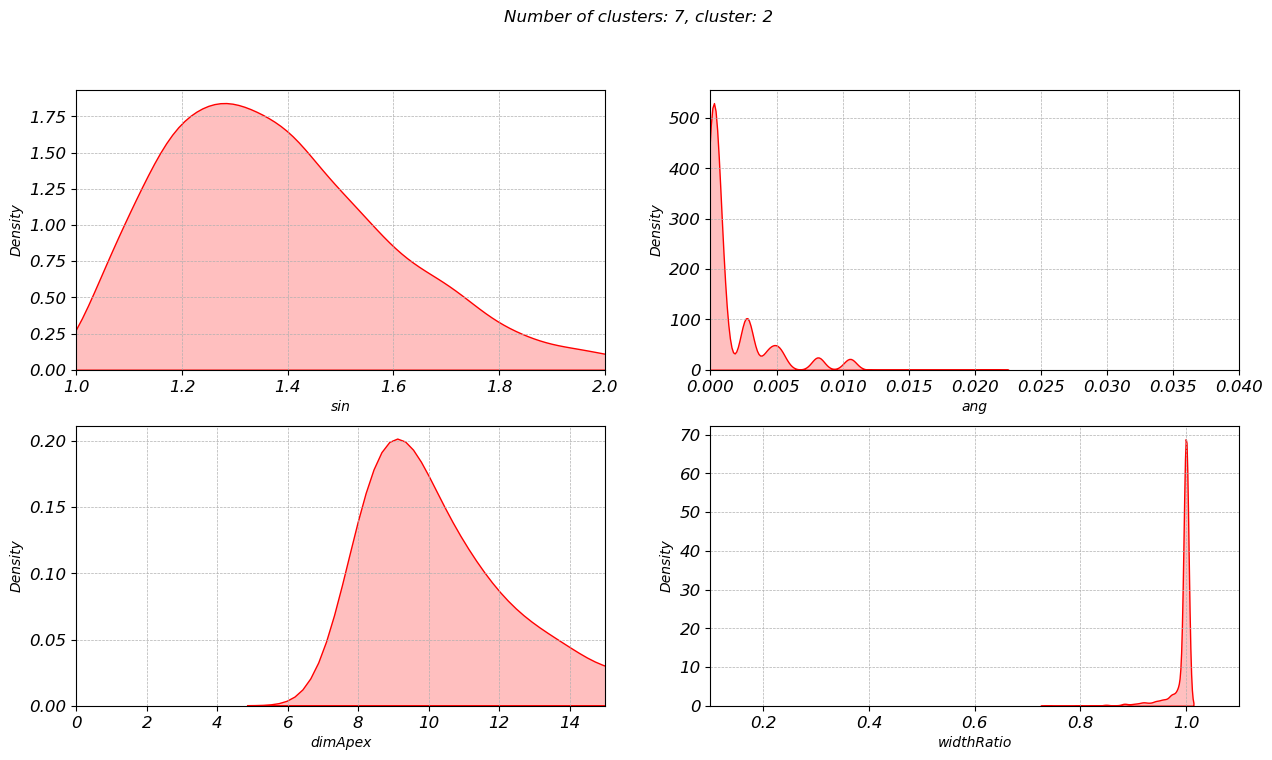

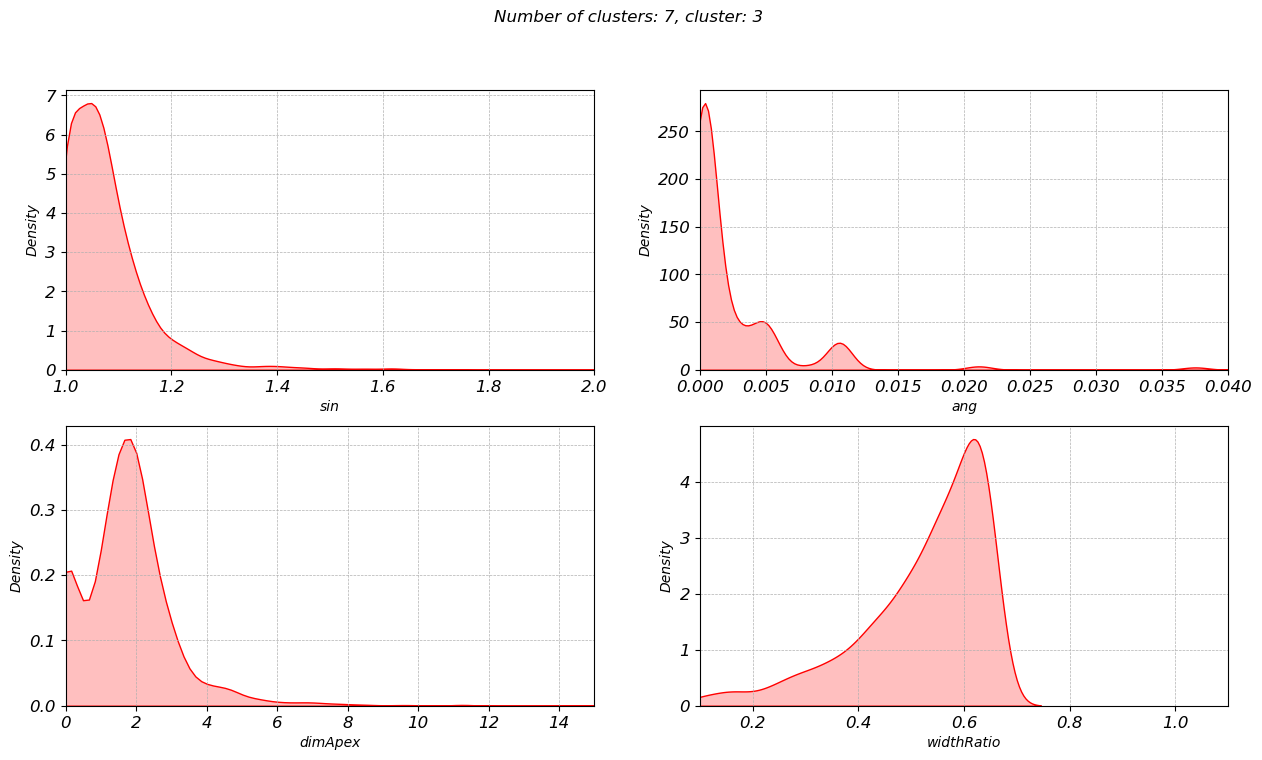

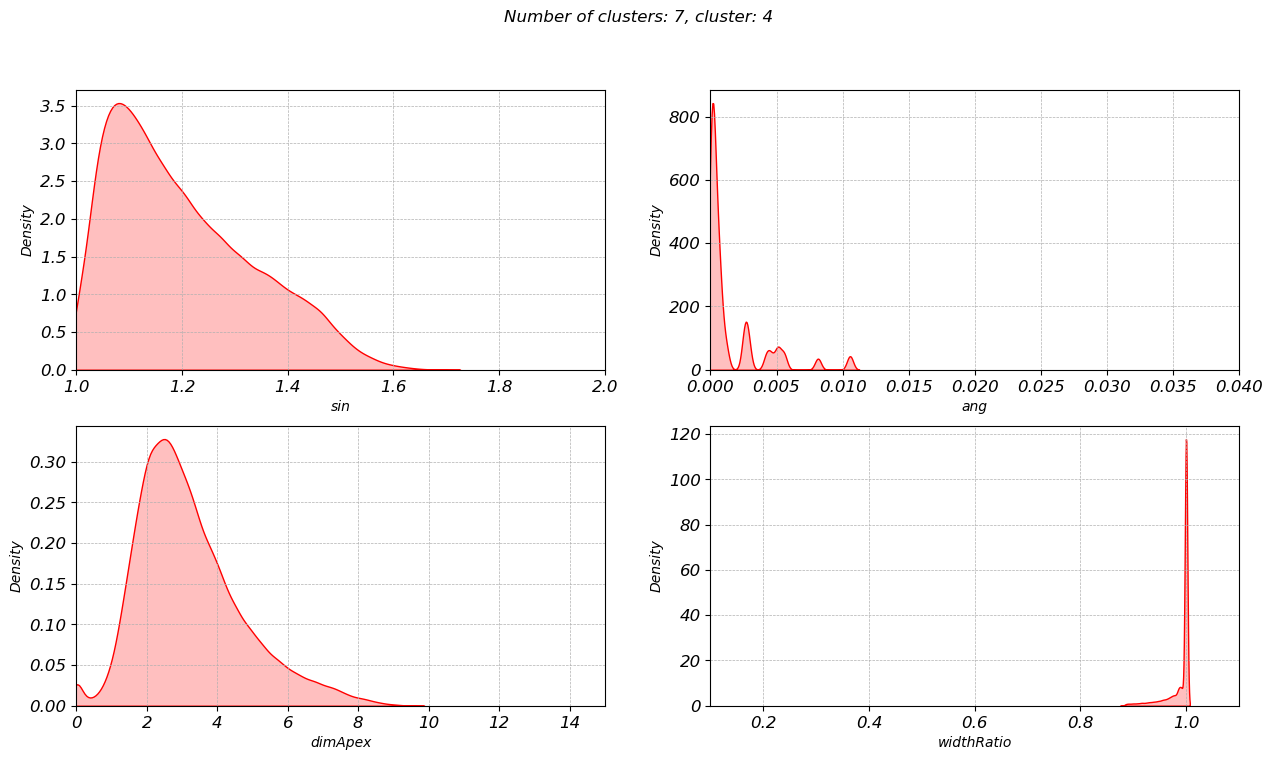

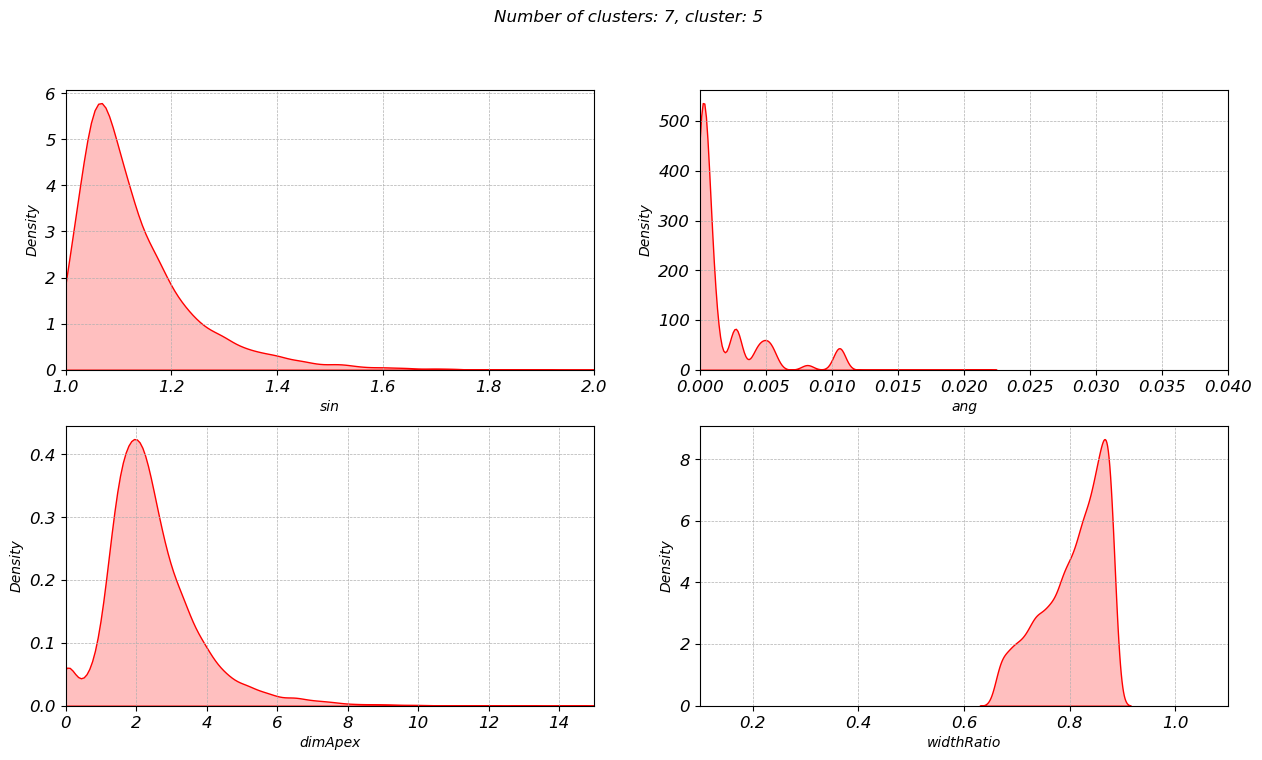

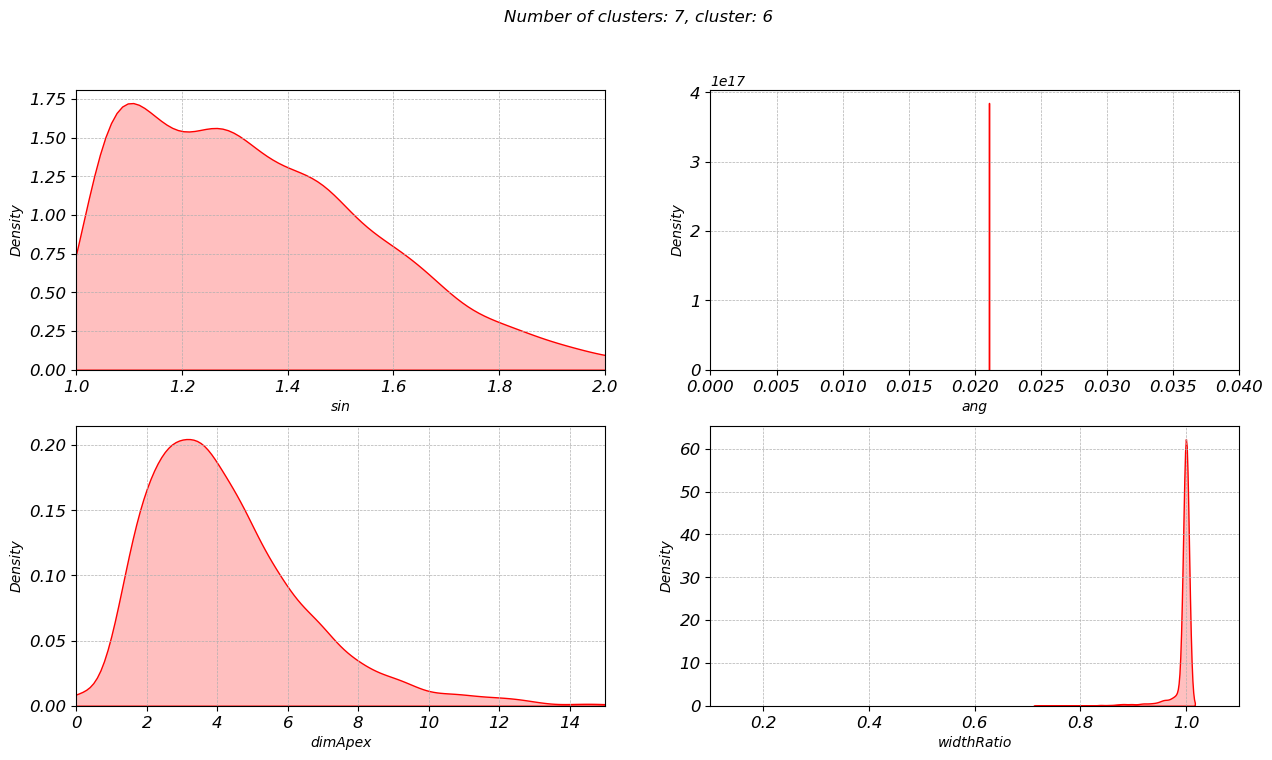

In [74]:

plot_kde_cluster(dfReachCluster, ['sin', 'ang', 'dimApex', 'widthRatio'],'GMM_pca_7_hard', 7 )

# Merge with GPKG

In [159]:
saveReachCols = ['combined_reach_id', 'file_cont',#, 'file_id',
                'sin', 'dimApex', 'ang', 'widthRatio',
                'KMeans_pca_8', 'KMeans_pca_3']
# saveBendCols  = ['combined_reach_id', 'file_cont', 'file_id','bendID',
#                 'sin', 'dimApex', 'ang', 'widthRatio',
#                 'KMeans_pca_5'
#                 ]
# dfReachSave = dfReachCluster[saveReachCols]

dfReachSave = dfReachCluster[saveReachCols]
# dfBendSave  = dfBendCluster[saveBendCols]

In [92]:
files = np.sort(glob(directory + f'results/new_segments/vector/*.gpkg'))
files[0][-29:-27]
files[0][-26:-24]

'00'

In [135]:
dire = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/results/new_segments/vector/'

In [138]:
def saveReachCluster_gpkg():
    files = np.sort(glob(dire + f'*.gpkg'))
    for i, f in tqdm(enumerate(files), total = len(files)):
        dfT = gpd.read_file(f)
        dfT['file_cont'] = f[-29:-27]
        dfT['file_id']   = f[-26:-24]
        if i == 0:
            dfS = dfT
        else:
            dfS = pd.concat([dfS, dfT], ignore_index = True)
            # print(cont)
            # keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
            # files = np.sort(glob(directory + f'results/new_segments/{cont}_??_50_02_conf.gpkg'))
    return dfS
dfR = saveReachCluster_gpkg()

100%|██████████| 43/43 [00:07<00:00,  5.89it/s]


In [138]:
gdf = gpd.read_file(f)
gdf = gdf[keepCols]

In [143]:
dfReachCluster

,file_cont,combined_reach_id,sin,widthRatio,dimApex,ang,sinLog,dimApexLog,widthRatioLog,angLog,PCA1,PCA2,PCA3,PCA4,kmeans_8,KMeans_pca_4,KMeans_pca_8,KMeans_pca_3
0,af,0.0,1.132492,1.000000,2.631801,2.037879e-03,0.090784,0.420364,0.001356,-2.690822,-0.358307,0.590732,0.338982,-0.139901,1,2,5,2
1,af,1.0,1.088588,0.894667,2.559186,1.138613e-03,0.075031,0.408216,-0.046823,-2.943624,-1.303699,-0.331237,-0.442247,-0.173505,1,2,6,2
2,af,2.0,1.057796,0.983000,1.715311,1.333394e-03,0.063632,0.234513,-0.006067,-2.875042,-1.105572,0.520535,0.432399,0.037170,7,2,2,2
3,af,3.0,1.109251,1.000000,3.024294,1.826298e-03,0.082516,0.480721,0.001356,-2.738428,-0.389813,0.407069,0.467546,-0.273081,1,2,2,2
4,af,4.0,1.233714,1.000000,3.785313,1.807589e-03,0.125063,0.578179,0.001356,-2.742900,0.186961,0.062730,0.343121,-0.065036,5,2,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140569,sa,26777.0,1.019269,1.000000,2.177220,2.096300e-04,0.048935,0.338036,0.001356,-3.678547,-1.331082,0.026625,1.066236,0.105085,1,2,2,2
140570,sa,26779.0,1.007975,1.000000,0.252780,2.749114e-02,0.044530,-0.596104,0.001356,-1.560807,5.661293,12.551464,-7.890154,-6.807809,3,3,4,1
140571,sa,26780.0,1.096667,1.000000,4.652523,1.661056e-03,0.077973,0.667751,0.001356,-2.779616,-0.062162,-0.121536,0.647873,-0.736221,5,2,1,2
140572,sa,26781.0,1.000000,0.849094,0.000000,1.556395e-14,0.041393,-3.172485,-0.069447,-13.807880,-2.777190,-0.266524,-0.604291,0.503610,0,0,6,0


In [160]:
gdf = dfR.merge(dfReachSave, how = 'left', on = ['file_cont', 'combined_reach_id'])

gdf = gdf.drop(['x', 'y', 'n_nodes', 'wse', 'wse_var', 'width_var',
          'obstr_type','grod_id','hfalls_id','swot_obs','pfaf1', 'pfaf2',
          'networkGroup', 'max_dist_out','up_reach_id', 'catchment_position'], axis = 1)
gdf.columns

Index(['reach_id', 'reach_len', 'width', 'facc', 'n_chan_max', 'n_chan_mod',
       'slope', 'dist_out', 'lakeflag', 'max_width', 'n_rch_up', 'n_rch_dn',
       'rch_id_up', 'rch_id_dn', 'swot_orbit', 'type', 'river_name',
       'edit_flag', 'trib_flag', 'path_freq', 'path_order', 'path_segs',
       'main_side', 'strm_order', 'end_reach', 'network', 'include_flag',
       'localCRS', 'rch_id_up_orig', 'rch_id_dn_orig', 'n_rch_up_orig',
       'n_rch_dn_orig', 'node_mean_max_width', 'dn_connected_reach',
       'networkGraph', 'up_connected_reach', 'river_segment',
       'river_segment_order', 'reach_order', 'combined_reach_id',
       'dn_river_segment', 'combined_reach_len', 'combined_reach_width',
       'combined_reach_max_width', 'combined_reach_up', 'combined_reach_dn',
       'geometry', 'file_cont', 'file_id', 'sin', 'dimApex', 'ang',
       'widthRatio', 'KMeans_pca_8', 'KMeans_pca_3'],
      dtype='object')

In [161]:
gdf.to_file('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/Congres/AGU_2025/presentation/analysis/global_cluster.gpkg')

In [142]:
A = dfReachCluster[dfReachCluster['file_cont'] == cont]
B = gdf.merge(A, how = 'left', on = 'combined_reach_id')

In [ ]:
for cont in ['af', 'eu', 'oc', 'as', 'sa', 'na']:
    keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
    files    = np.sort(glob(directory + f'results/single_values/{cont}_??_50_02_conf.gpkg'))
    dfS      = dfReachSave[dfReachSave['file_cont'] == cont]
    # dfS = dfS.drop(['PCA1', 'PCA2', 'PCA3', 'PCA4'], axis = 1)
    for f in tqdm(files):
        gdf = gpd.read_file(f)
        gdf = gdf[keepCols]
    
        gdf = gdf.drop(['bendDistOut'], axis = 1)
        
        gdfN = gdf.merge(dfS, on = 'combined_reach_id', how = 'left')

        gdfN.to_file(directory + f'results/cluster/{cont}_{f[-18:-16]}_bend_cluster_morph2.gpkg', driver = 'GPKG')

100%|██████████| 7/7 [01:19<00:00, 11.35s/it]


In [131]:
# def saveBendCluster_gpkg():
for cont in ['af', 'eu', 'oc', 'as', 'sa', 'na']:
# for cont in ['na']:
    keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
    files    = np.sort(glob(directory + f'results/single_values/{cont}_??_50_02_conf.gpkg'))
    dfS      = dfBendSave[dfBendSave['file_cont'] == cont]
    for f in tqdm(files):
        gdf = gpd.read_file(f)
        gdf = gdf[keepCols]
    
        # add bendRank
        gdf['bendRank'] = gdf.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
        gdf['bendID']   = gdf['combined_reach_id'].astype(int).astype(str) + '_' + gdf['bendRank'].astype(str)
        gdf = gdf.drop(['combined_reach_id','bendDistOut'], axis = 1)
        
        gdfN = gdf.merge(dfS, on = 'bendID', how = 'left')

        gdfN.to_file(directory + f'results/cluster/{cont}_{f[-18:-16]}_bend_cluster_morph.gpkg', driver = 'GPKG')

100%|██████████| 7/7 [01:11<00:00, 10.24s/it]


In [129]:
f[-18:-16]

'00'

In [154]:
A['ang']

0       [-0.00356979,  0.000901  , -0.007191  ,  0.000...
1       [-1.08052933e-03,  3.85787624e-03, -2.32591043...
2       [-2.73267757e-06,  3.88166117e-04, -1.01896127...
3       [-2.73267757e-06,  3.88166117e-04, -1.01896127...
4       [-0.00152417,  0.00189413, -0.00335872,  0.005...
                              ...                        
1254    [-4.74422093e-06,  6.95886707e-04, -2.81728184...
1255    [-4.74422093e-06,  6.95886707e-04, -2.81728184...
1256                                                  NaN
1257                                                  NaN
1258                                                  NaN
Name: ang, Length: 1259, dtype: object

In [153]:
A = pd.read_csv(glob(directory + 'results/all/*')[1])

In [150]:
B = dfReachCluster[(dfReachCluster['file_cont'] == 'na') & (dfReachCluster['file_id'] == '04')]


In [152]:
B.ang.unique()

array([3.39450721e+11])